# Importing libraries

In [9]:
!pip install ucimlrepo rpy2
!R -e 'install.packages(c("tclust", "lme4"), repos="https://cloud.r-project.org")'

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rpy2.robjects as robjects
import seaborn as sns
import statsmodels.api as sm

from rpy2.robjects import numpy2ri, pandas2ri
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist, squareform
from scipy.stats import chi2, gaussian_kde
from sklearn.covariance import EmpiricalCovariance, MinCovDet
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    adjusted_mutual_info_score,
    adjusted_rand_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")


R version 4.6.1 (2026-06-24) -- "Happy Hop"
Copyright (C) 2026 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> install.packages(c("tclust", "lme4"), repos="https://cloud.r-project.org")
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/tclust_2.2-0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/lme4_2.0-6.tar.gz'
* installing *source

# PART I — Data understanding


## 1. Initial Dataset Loading and Inspection

This section introduces the Taiwanese Bankruptcy Prediction dataset and provides an initial assessment of its structure and quality.

The analysis includes:
- Dataset loading from the UCI Repository
- Feature and target extraction
- DataFrame construction
- Descriptive statistics
- Missing-value inspection
- Duplicate-observation detection
- Target-variable distribution
- Initial Spearman correlation analysis

The objective is to understand the dataset before proceeding with exploratory and predictive analyses.




Missing values in features: 0
Missing values in target: 0
Number of duplicate rows in features: 0


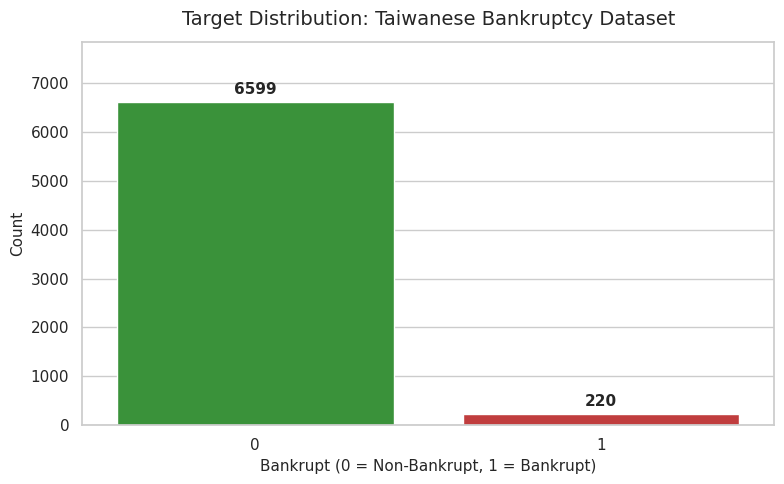

Training set shape: (5455, 95) (Bankrupt cases: 176)
Test set shape:     (1364, 95) (Bankrupt cases: 44)


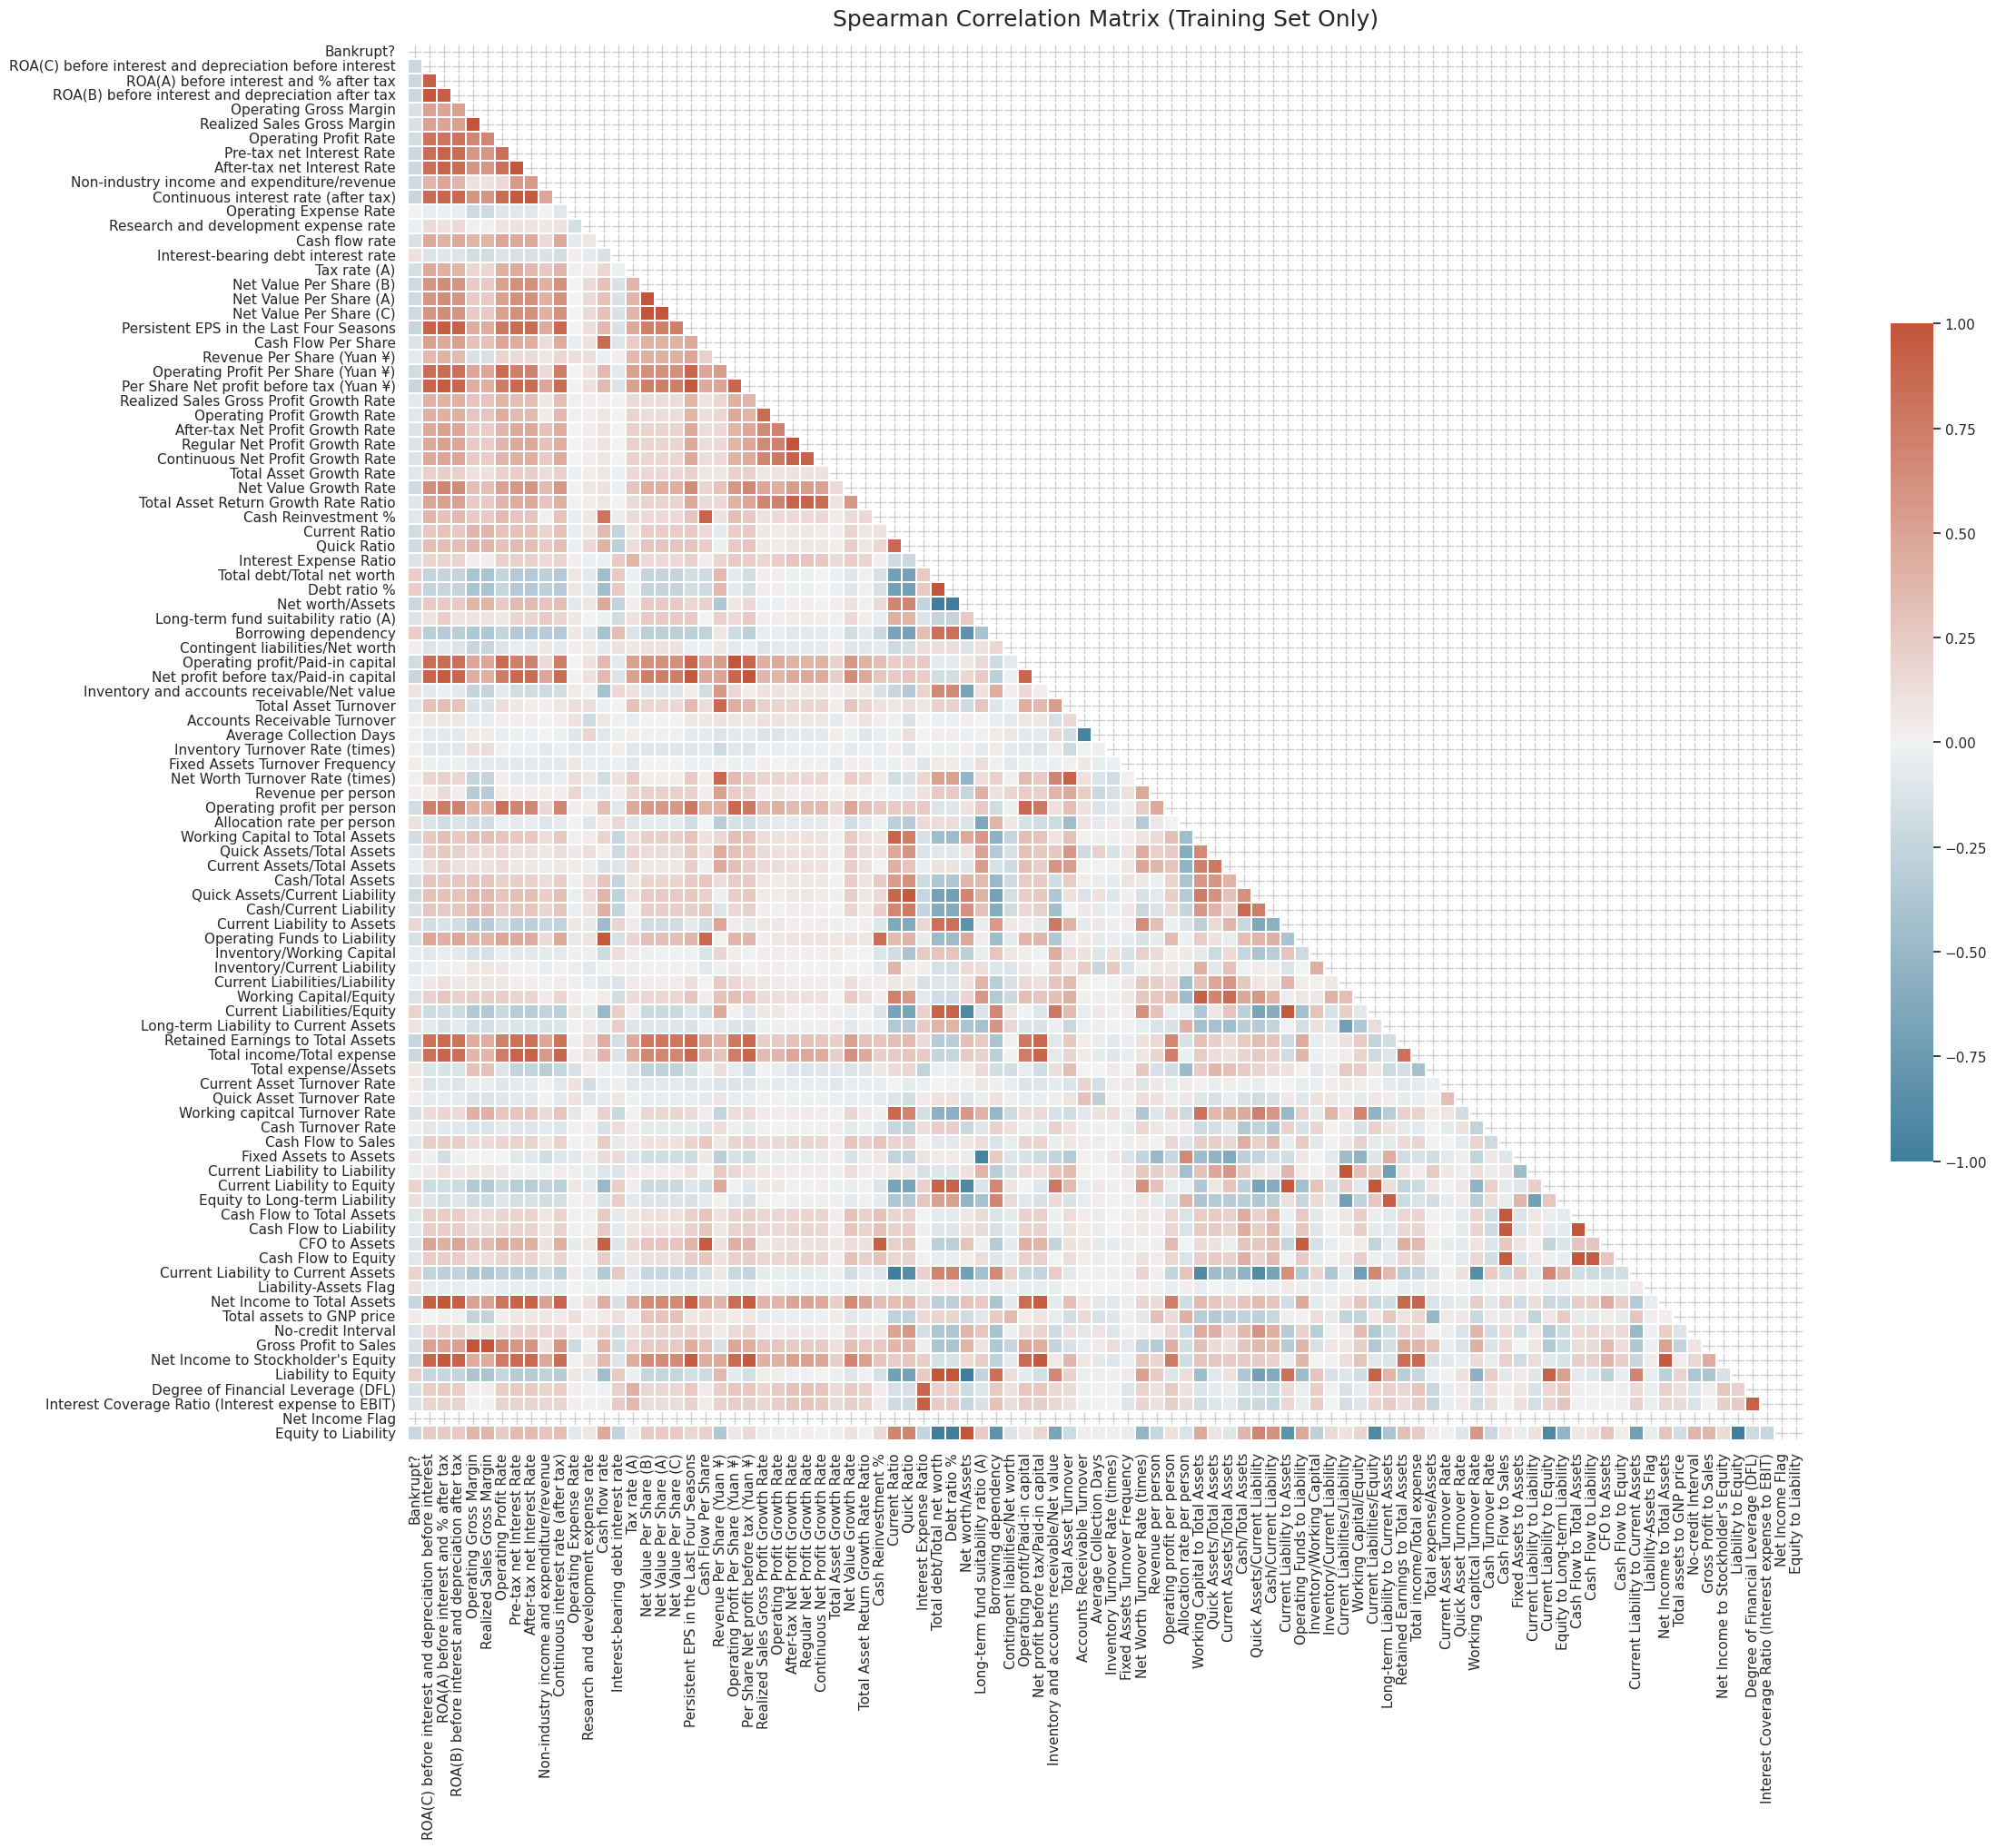

In [10]:
"""
Research Questions:
1. Which financial ratios best discriminate between bankrupt and non-bankrupt firms under high class imbalance?
2. How do robust clustering approaches (TCLUST) compare to probabilistic clustering (GMM) in detecting underlying financial profiles and multivariate anomalies?
3. What is the predictive performance and calibration of regularized and ensemble models under nested cross-validation?
"""

# Fetch dataset from UCI Repository (ID 572: Taiwanese Bankruptcy Prediction)
taiwanese_bankruptcy_prediction = fetch_ucirepo(id=572)

# Extract features (X) and target (y)
X = taiwanese_bankruptcy_prediction.data.features.copy()
y = taiwanese_bankruptcy_prediction.data.targets.copy()

# Ensure target is 1D series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# Standardize column names (remove leading/trailing whitespaces)
X.columns = X.columns.str.strip()
y.name = 'Bankrupt?'

# Check dataset integrity
print("Missing values in features:", X.isna().sum().sum())
print("Missing values in target:", y.isna().sum())
print("Number of duplicate rows in features:", int(X.duplicated().sum()))

# Target distribution check (dataset-level)
counts = y.value_counts()
stable_pct = round(counts[0] / len(y) * 100, 2)
unstable_pct = round(counts[1] / len(y) * 100, 2)

# Plot class balance
sns.set_theme(style="whitegrid")
custom_palette = {0: "#2ca02c", 1: "#d62728"}
labels = {0: f'Financially stable: {stable_pct}%', 1: f'Financially unstable: {unstable_pct}%'}

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x=y, palette=custom_palette, hue=y, legend=False, ax=ax)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            xytext=(0, 4),
            textcoords='offset points'
        )

ax.set_title('Target Distribution: Taiwanese Bankruptcy Dataset', fontsize=14, pad=12)
ax.set_xlabel('Bankrupt (0 = Non-Bankrupt, 1 = Bankrupt)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_ylim(0, len(y) * 1.15)
plt.tight_layout()
plt.show()

# Partition data into Train and Test sets before any data-driven decisions
# Test set remains untouched for final out-of-sample evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape} (Bankrupt cases: {y_train.sum()})")
print(f"Test set shape:     {X_test.shape} (Bankrupt cases: {y_test.sum()})")

# Feature correlation matrix computed strictly on the training set
train_df = pd.concat([y_train, X_train], axis=1)
spearman_corr = train_df.corr(method='spearman')

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(24, 20))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    spearman_corr,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.6},
    ax=ax
)
ax.set_title('Spearman Correlation Matrix (Training Set Only)', fontsize=18, pad=15)
plt.tight_layout()
plt.show()

## 2. Pre-EDA: Distribution, Shape, and Outlier Analysis

This section explores the statistical properties of the financial variables before feature selection and modeling.

The analysis focuses on:
- Distribution analysis through histograms and KDE plots
- Skewness and kurtosis
- Mean, median, and standard deviation
- Identification of highly asymmetric features
- Identification of features with heavy tails
- IQR-based outlier detection
- Boxplot visualization of the features with the largest number of outliers

The objective is to assess the distributional characteristics of the financial ratios and identify potential outlier-related issues.

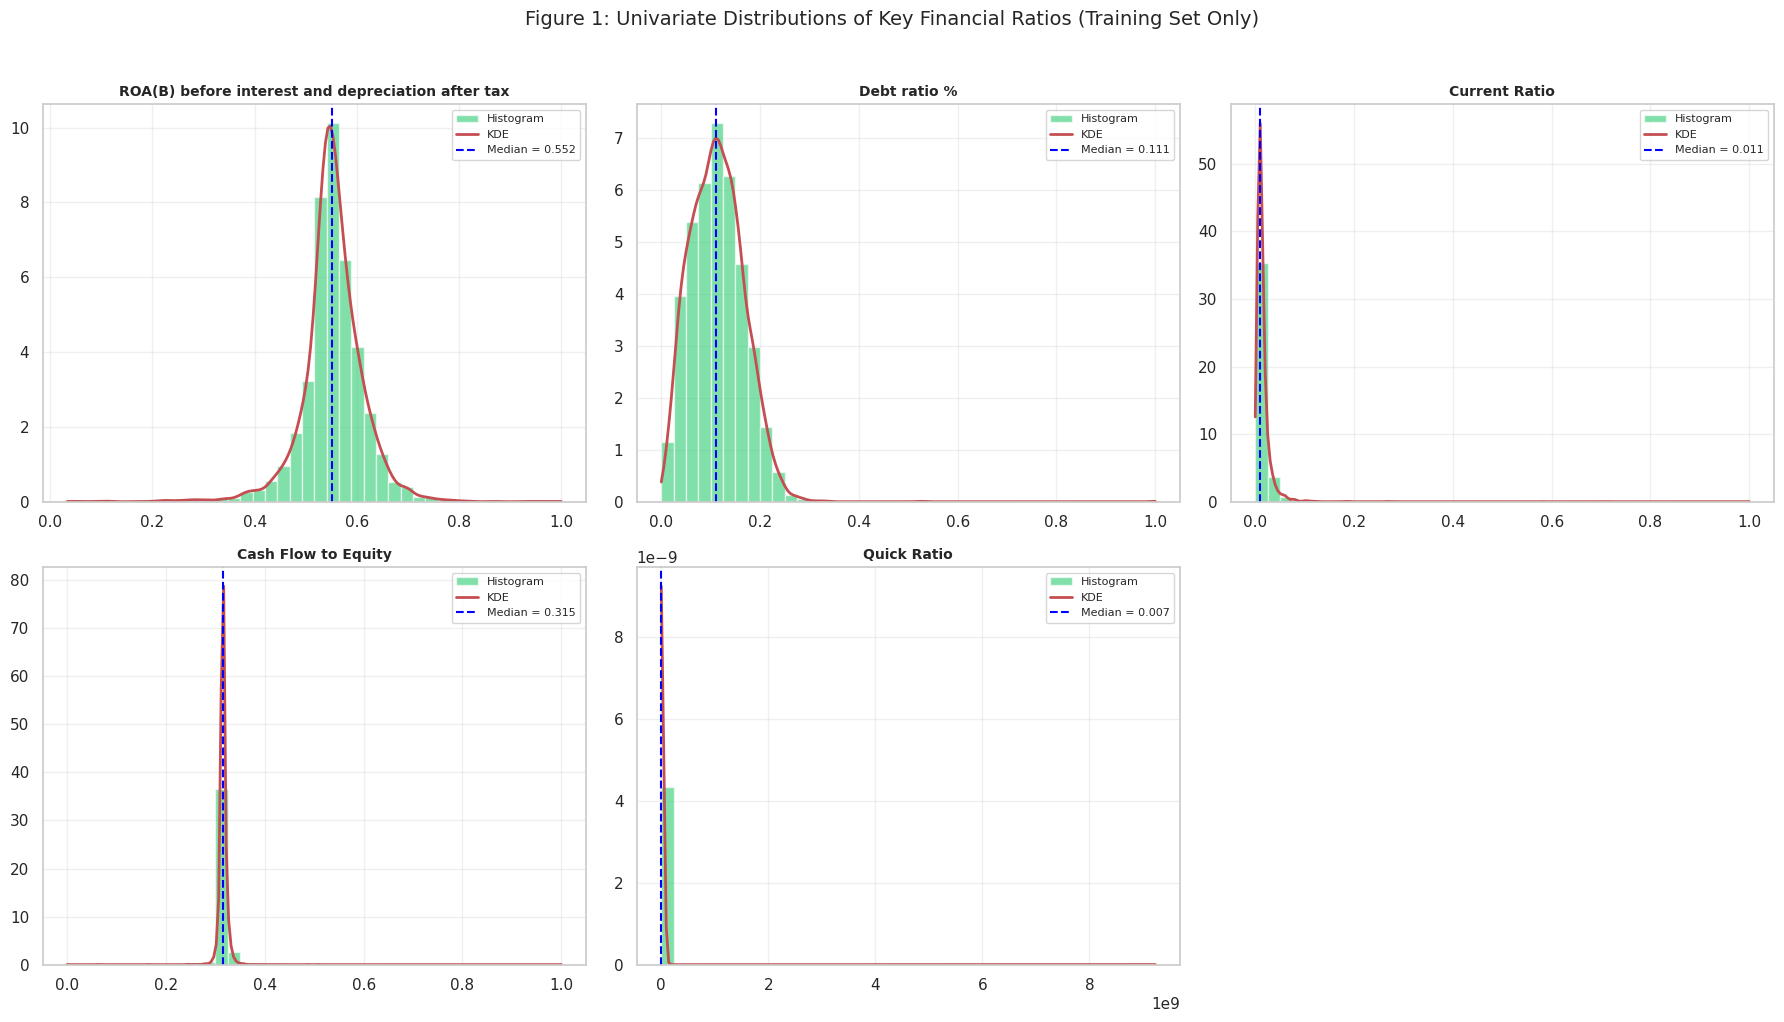

TOP 10 TRAINING FEATURES BY ABSOLUTE SKEWNESS
                                      Skewness   Kurtosis          Mean  Median           Std
Net Value Growth Rate                  73.8580  5455.0000  2.474794e+05  0.0005  1.827832e+07
Fixed Assets to Assets                 73.8580  5455.0000  1.525206e+06  0.1995  1.126486e+08
Revenue per person                     73.8580  5455.0000  1.615032e+06  0.0185  1.192830e+08
Total income/Total expense             73.6964  5438.9869  2.600000e-03  0.0023  1.350000e-02
Operating Profit Rate                 -73.3637  5405.5594  9.988000e-01  0.9990  1.360000e-02
Contingent liabilities/Net worth       71.8510  5253.0992  6.000000e-03  0.0054  1.360000e-02
Operating Profit Growth Rate          -69.0960  4971.8724  8.479000e-01  0.8480  1.180000e-02
Working capitcal Turnover Rate         67.0864  4727.6686  5.941000e-01  0.5940  5.700000e-03
Total Asset Return Growth Rate Ratio  -63.8841  4508.4972  2.641000e-01  0.2640  3.800000e-03
Continuous int

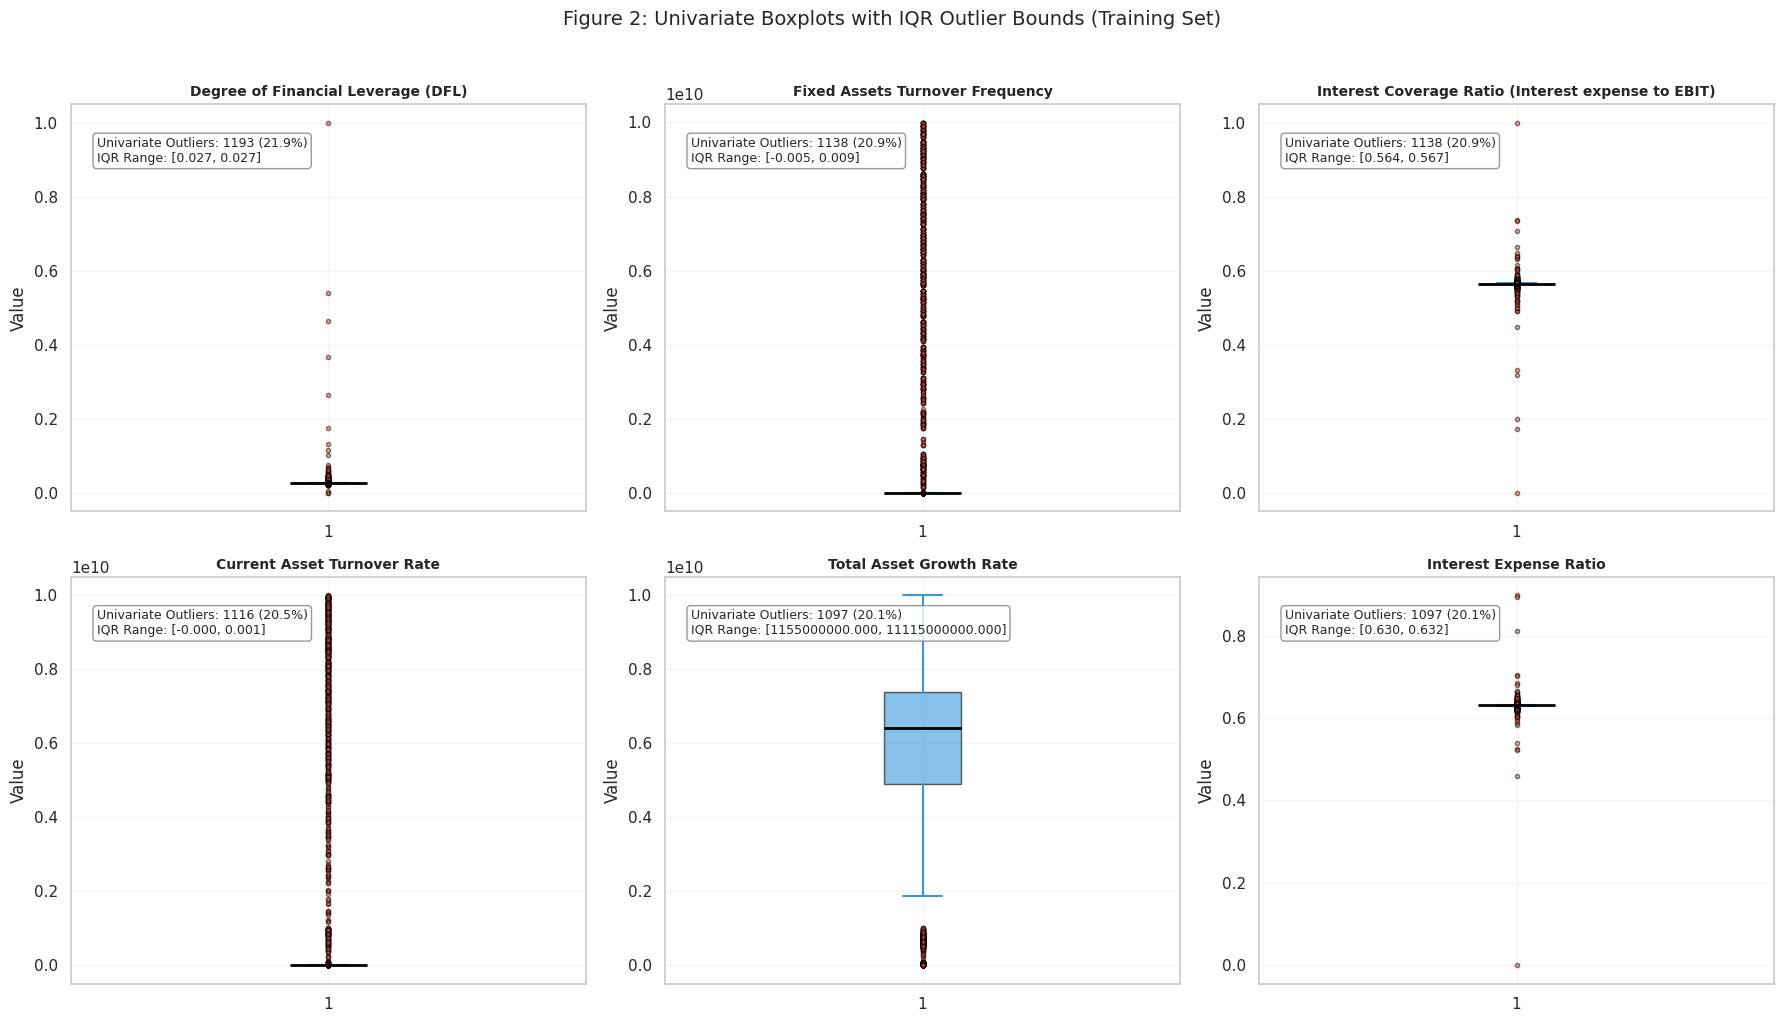

In [11]:
# PHASE 1a: DISTRIBUTIONS (Key features evaluated strictly on X_train)
key_features = [
    'ROA(B) before interest and depreciation after tax',
    'Debt ratio %',
    'Current Ratio',
    'EBIT to Total Assets',
    'Cash Flow to Equity',
    'Quick Ratio'
]

# Ensure features are present in the training set
valid_key_features = [f for f in key_features if f in X_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, feat in enumerate(valid_key_features):
    ax = axes[i]
    data = X_train[feat].dropna()

    ax.hist(data, bins=40, density=True, alpha=0.6, color='#2ecc71', edgecolor='white', label='Histogram')

    # Kernel Density Estimation
    kde = gaussian_kde(data)
    kde_x = np.linspace(data.min(), data.max(), 200)
    ax.plot(kde_x, kde(kde_x), 'r-', linewidth=2, label='KDE')

    ax.axvline(data.median(), color='blue', linestyle='--', linewidth=1.5, label=f"Median = {data.median():.3f}")
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(len(valid_key_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Figure 1: Univariate Distributions of Key Financial Ratios (Training Set Only)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# PHASE 1b: SHAPE STATISTICS — Skewness and Kurtosis on Training Features
stats = pd.DataFrame({
    'Skewness': X_train.skew(),
    'Kurtosis': X_train.kurtosis(),
    'Mean': X_train.mean(),
    'Median': X_train.median(),
    'Std': X_train.std()
}).round(4)

stats['Abs_Skewness'] = stats['Skewness'].abs()
stats_sorted_skew = stats.sort_values('Abs_Skewness', ascending=False)

print("=" * 80)
print("TOP 10 TRAINING FEATURES BY ABSOLUTE SKEWNESS")
print("=" * 80)
print(stats_sorted_skew[['Skewness', 'Kurtosis', 'Mean', 'Median', 'Std']].head(10).to_string())

# PHASE 1c: UNIVARIATE OUTLIER DETECTION (Tukey's IQR Method)
def calculate_iqr_outliers(series):
    # Classical univariate IQR rule: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (series < lower_bound) | (series > upper_bound)
    return outlier_mask.sum(), lower_bound, upper_bound

univariate_outlier_counts = X_train.apply(lambda col: calculate_iqr_outliers(col.dropna())[0])
top_univariate_outliers = univariate_outlier_counts.nlargest(6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(top_univariate_outliers.index):
    ax = axes[i]
    data = X_train[col].dropna()
    n_outliers, q_low, q_high = calculate_iqr_outliers(data)

    ax.boxplot(
        data,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='#3498db', alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(color='#3498db', linewidth=1.5),
        capprops=dict(color='#3498db', linewidth=1.5),
        flierprops=dict(markerfacecolor='#e74c3c', marker='o', markersize=3, alpha=0.5)
    )

    ax.text(
        0.05, 0.92,
        f"Univariate Outliers: {n_outliers} ({n_outliers/len(data):.1%})\nIQR Range: [{q_low:.3f}, {q_high:.3f}]",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8)
    )
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.2)

plt.suptitle('Figure 2: Univariate Boxplots with IQR Outlier Bounds (Training Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# PART II — Data structure and robustness


## 3. Redundancy Analysis and Hierarchical Dendrogram

This section investigates redundancy among the financial predictors.

The analysis includes:
- Removal of constant features
- Computation of the absolute Spearman correlation matrix
- Identification of highly correlated feature pairs
- Removal of redundant predictors
- Hierarchical clustering of the remaining features
- Visualization through a dendrogram

The objective is to reduce multicollinearity and obtain a more compact set of informative predictors.

Dropping zero-variance columns from training set: ['Net Income Flag']
Training features after zero-variance check: 94
Features removed by Spearman redundancy threshold (0.8): 53
Remaining features: 41


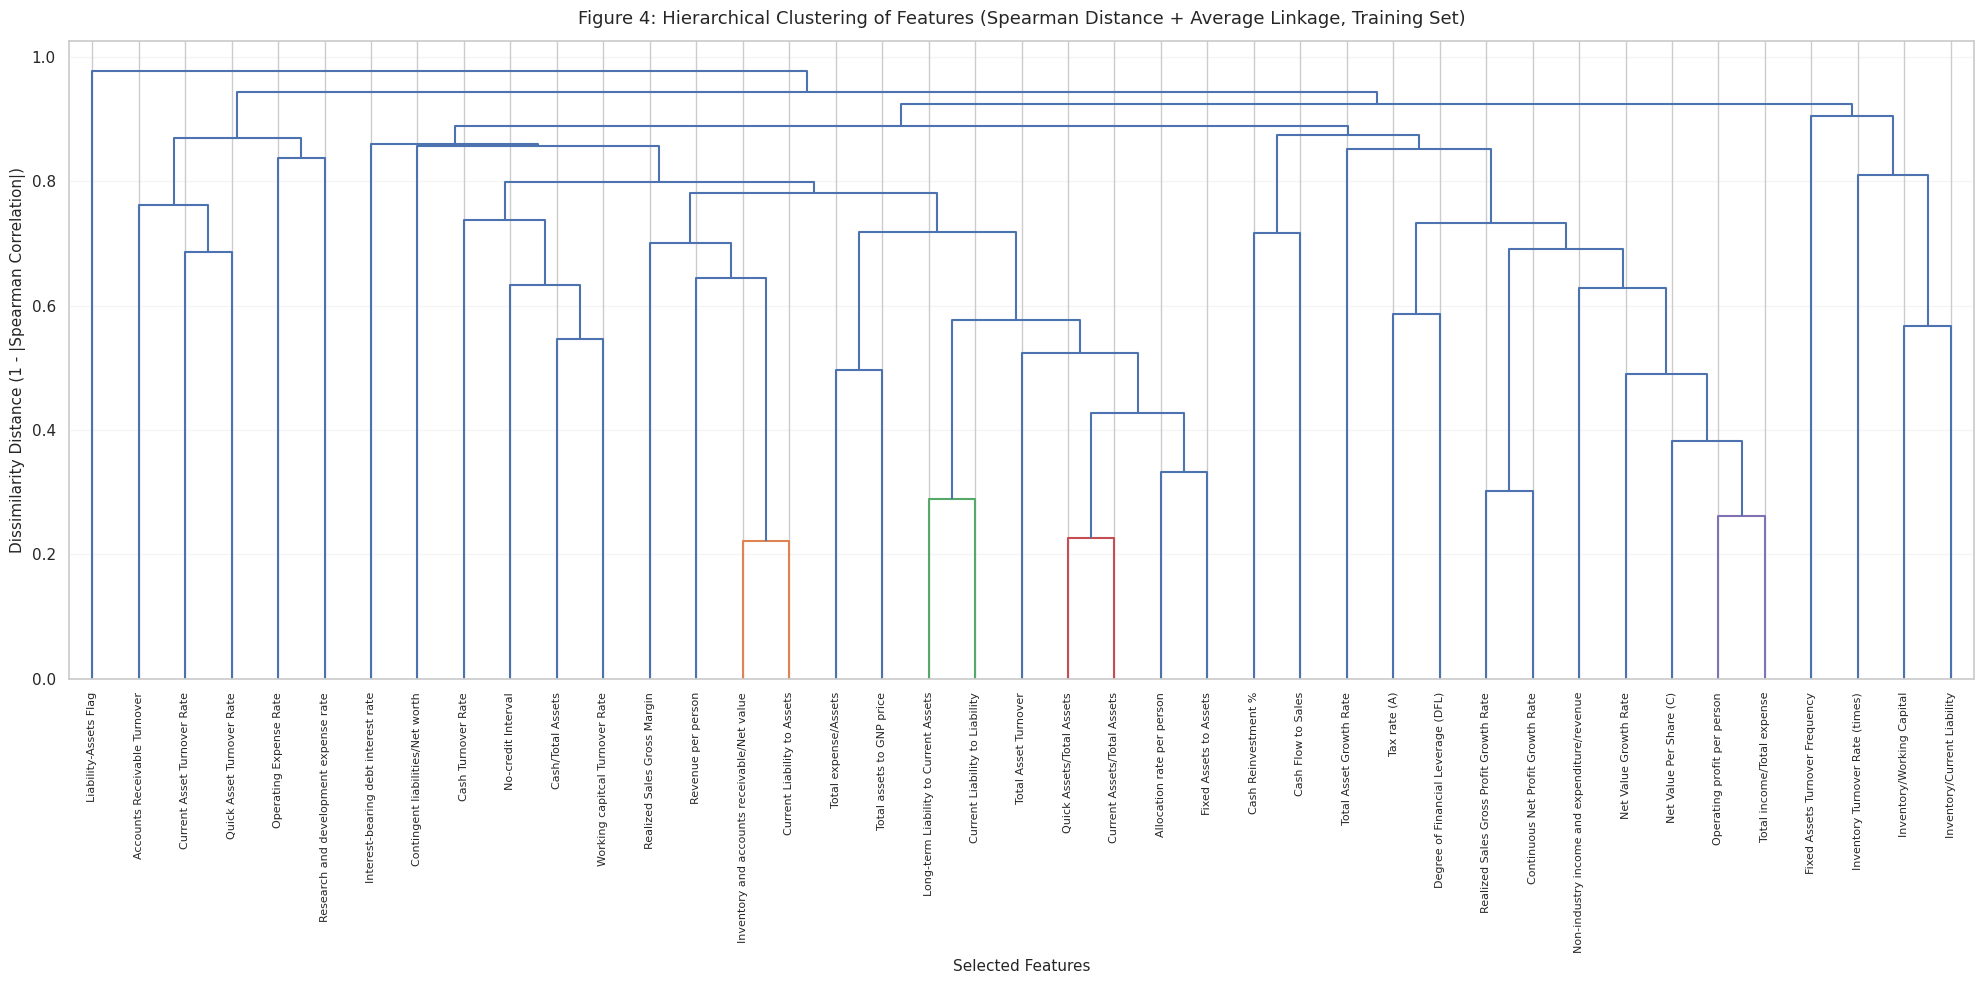

In [12]:
# 1. Zero-variance screening strictly on the training set
zero_var_cols = X_train.columns[X_train.nunique() <= 1].tolist()
if zero_var_cols:
    print(f"Dropping zero-variance columns from training set: {zero_var_cols}")
    X_train_filtered = X_train.drop(columns=zero_var_cols)
    X_test_filtered = X_test.drop(columns=zero_var_cols)
else:
    print("No zero-variance columns found in training set.")
    X_train_filtered = X_train.copy()
    X_test_filtered = X_test.copy()

print(f"Training features after zero-variance check: {X_train_filtered.shape[1]}")

# 2. Redundancy analysis computed strictly on X_train_filtered
spearman_abs_train = X_train_filtered.corr(method='spearman').abs()

threshold = 0.80
to_drop = set()

# Iterate over feature pairs exceeding the correlation threshold
# Keep the feature that has lower average correlation with the remaining feature set
for i in range(spearman_abs_train.shape[1]):
    for j in range(i):
        if spearman_abs_train.iloc[i, j] > threshold:
            col_i = spearman_abs_train.columns[i]
            col_j = spearman_abs_train.columns[j]
            corr_i = spearman_abs_train[col_i].drop([col_i, col_j]).mean()
            corr_j = spearman_abs_train[col_j].drop([col_i, col_j]).mean()
            if corr_i > corr_j:
                to_drop.add(col_i)
            else:
                to_drop.add(col_j)

# Apply reduction learned from training data to both Train and Test sets
selected_features = [c for c in X_train_filtered.columns if c not in to_drop]
X_train_reduced = X_train_filtered[selected_features].copy()
X_test_reduced = X_test_filtered[selected_features].copy()

print(f"Features removed by Spearman redundancy threshold ({threshold}): {len(to_drop)}")
print(f"Remaining features: {len(selected_features)}")

# 3. Hierarchical Clustering on Training Features
# Methodological verification: Ward's linkage strictly requires Euclidean distances.
# Non-Euclidean correlation distances (e.g., 1 - |r|) violate the Lance-Williams recurrence for Ward
# and produce invalid dendrogram merges. Average linkage is geometrically valid for correlation distances.
dist_matrix = 1.0 - spearman_abs_train.loc[selected_features, selected_features]

# Ensure zero on diagonal and values bounded in [0, 1]
np.fill_diagonal(dist_matrix.values, 0.0)
dist_matrix = dist_matrix.clip(lower=0.0, upper=1.0)

dist_condensed = squareform(dist_matrix.values, checks=True)

# Using 'average' linkage for valid agglomeration with correlation-based distance metric
Z_average = linkage(dist_condensed, method='average')

# Figure configuration
fig, ax = plt.subplots(figsize=(20, 10))
dendrogram(
    Z_average,
    labels=selected_features,
    leaf_font_size=8,
    leaf_rotation=90,
    color_threshold=0.3,
    ax=ax
)
ax.set_title('Figure 4: Hierarchical Clustering of Features (Spearman Distance + Average Linkage, Training Set)', fontsize=13, pad=12)
ax.set_xlabel('Selected Features', fontsize=11)
ax.set_ylabel('Dissimilarity Distance (1 - |Spearman Correlation|)', fontsize=11)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

## 4. Robust Covariance Estimation (MCD) and Outlier Map

This section investigates multivariate outliers using both classical and robust covariance estimation.

The analysis includes:
- Classical empirical covariance estimation
- Classical Mahalanobis distances
- Minimum Covariance Determinant (MCD) estimation
- Robust Mahalanobis distances
- Chi-square-based cutoff identification
- Distance-Distance Outlier Map
- Classification of observations into regular observations, leverage points, and vertical outliers

The objective is to assess the influence of multivariate outliers and compare classical and robust measures of distance.

MULTIVARIATE ROBUST COVARIANCE DIAGNOSTICS (TRAIN SET: p = 41)
Theoretical Chi-Square Cutoff (alpha = 0.025, df = 41): 60.561
Regular Observations (Concordant Inliers):       4468 (81.91%)
Masked Outliers (Revealed exclusively by MCD):  845 (15.49%)
Swamped Inliers (Classical false alarms):        4 (0.07%)
Severe Multivariate Outliers (Both detectors):  138 (2.53%)


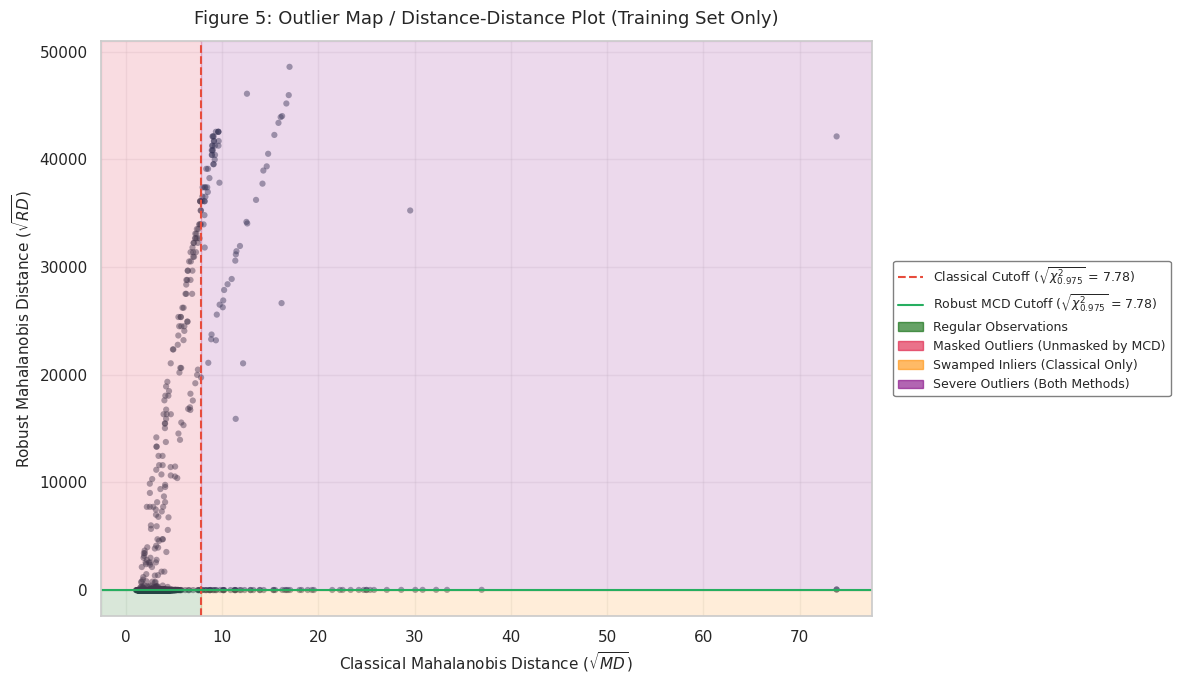

SKEWNESS COMPARISON: RAW vs YEO-JOHNSON (TRAINING SET)
                                    Skewness_Raw  Skewness_YeoJohnson  Absolute_Skewness_Reduction
Fixed Assets to Assets                   73.8580               0.1645                      73.6935
Total income/Total expense               73.6964               0.0857                      73.6107
Revenue per person                       73.8580               0.8092                      73.0488
Contingent liabilities/Net worth         71.8510              -1.8580                      69.9930
Working capitcal Turnover Rate           67.0864               0.0000                      67.0864
Cash Flow to Sales                       60.8659               0.0000                      60.8659
Net Value Growth Rate                    73.8580              17.2530                      56.6050
Continuous Net Profit Growth Rate        60.5836             -13.9593                      46.6242
Inventory/Working Capital                51.6628      

In [13]:
# Methodological Note:
# 1. MCD and Empirical Covariance estimators must be fit strictly on X_train_reduced to prevent data leakage.
# 2. Outlier classification thresholds derived from training parameters can then be evaluated on out-of-sample data if needed.
# 3. Terminology clarification: In unsupervised multivariate feature spaces without a regression response,
#    quadrants distinguish: Regular observations, Masked outliers (revealed by MCD), Classical-only outliers (swamping),
#    and Severe multivariate anomalies detected by both estimators.

# 1. Fit classical empirical covariance on training data
emp_cov_train = EmpiricalCovariance().fit(X_train_reduced)
classical_mahalanobis_train = emp_cov_train.mahalanobis(X_train_reduced)

# 2. Fit robust Minimum Covariance Determinant (MCD) on training data
# support_fraction=0.75 provides a breakdown point of 25% while maintaining computational efficiency
mcd_cov_train = MinCovDet(support_fraction=0.75, random_state=42).fit(X_train_reduced)
robust_mahalanobis_train = mcd_cov_train.mahalanobis(X_train_reduced)

# 3. Theoretical cutoff based on Chi-Square distribution (p = number of features, alpha = 0.025)
p_features = X_train_reduced.shape[1]
cutoff_train = chi2.ppf(0.975, df=p_features)

# Calculate diagnostic subgroups
regular_obs = np.sum((classical_mahalanobis_train <= cutoff_train) & (robust_mahalanobis_train <= cutoff_train))
masked_outliers = np.sum((classical_mahalanobis_train <= cutoff_train) & (robust_mahalanobis_train > cutoff_train))
swamped_outliers = np.sum((classical_mahalanobis_train > cutoff_train) & (robust_mahalanobis_train <= cutoff_train))
severe_outliers = np.sum((classical_mahalanobis_train > cutoff_train) & (robust_mahalanobis_train > cutoff_train))

print("=" * 80)
print(f"MULTIVARIATE ROBUST COVARIANCE DIAGNOSTICS (TRAIN SET: p = {p_features})")
print(f"Theoretical Chi-Square Cutoff (alpha = 0.025, df = {p_features}): {cutoff_train:.3f}")
print("=" * 80)
print(f"Regular Observations (Concordant Inliers):       {regular_obs} ({regular_obs/len(X_train_reduced):.2%})")
print(f"Masked Outliers (Revealed exclusively by MCD):  {masked_outliers} ({masked_outliers/len(X_train_reduced):.2%})")
print(f"Swamped Inliers (Classical false alarms):        {swamped_outliers} ({swamped_outliers/len(X_train_reduced):.2%})")
print(f"Severe Multivariate Outliers (Both detectors):  {severe_outliers} ({severe_outliers/len(X_train_reduced):.2%})")
print("=" * 80)

# 4. Outlier Map (Distance-Distance Plot with square-root scaling for visual clarity)
fig, ax = plt.subplots(figsize=(12, 7))

# Plot sqrt(distances) to compress long tails and maintain readability
sqrt_classical = np.sqrt(classical_mahalanobis_train)
sqrt_robust = np.sqrt(robust_mahalanobis_train)
sqrt_cutoff = np.sqrt(cutoff_train)

ax.scatter(sqrt_classical, sqrt_robust, alpha=0.45, color='#2c3e50', edgecolors='none', s=20)
ax.axvline(x=sqrt_cutoff, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Classical Cutoff ($\sqrt{{\chi^2_{{0.975}}}}$ = {sqrt_cutoff:.2f})')
ax.axhline(y=sqrt_cutoff, color='#27ae60', linestyle='-', linewidth=1.5, label=f'Robust MCD Cutoff ($\sqrt{{\chi^2_{{0.975}}}}$ = {sqrt_cutoff:.2f})')

import matplotlib.patches as mpatches

xlim = ax.get_xlim()
ylim = ax.get_ylim()

alpha_bg = 0.15

rect_regular = mpatches.Rectangle((xlim[0], ylim[0]), sqrt_cutoff - xlim[0], sqrt_cutoff - ylim[0], color='darkgreen', alpha=alpha_bg)
rect_swamped = mpatches.Rectangle((sqrt_cutoff, ylim[0]), xlim[1] - sqrt_cutoff, sqrt_cutoff - ylim[0], color='darkorange', alpha=alpha_bg)
rect_masked  = mpatches.Rectangle((xlim[0], sqrt_cutoff), sqrt_cutoff - xlim[0], ylim[1] - sqrt_cutoff, color='crimson', alpha=alpha_bg)
rect_severe  = mpatches.Rectangle((sqrt_cutoff, sqrt_cutoff), xlim[1] - sqrt_cutoff, ylim[1] - sqrt_cutoff, color='purple', alpha=alpha_bg)

ax.add_patch(rect_regular)
ax.add_patch(rect_swamped)
ax.add_patch(rect_masked)
ax.add_patch(rect_severe)

ax.set_xlim(xlim)
ax.set_ylim(ylim)

alpha_leg = 0.6
patch_reg = mpatches.Patch(color='darkgreen', alpha=alpha_leg, label='Regular Observations')
patch_msk = mpatches.Patch(color='crimson', alpha=alpha_leg, label='Masked Outliers (Unmasked by MCD)')
patch_swp = mpatches.Patch(color='darkorange', alpha=alpha_leg, label='Swamped Inliers (Classical Only)')
patch_svr = mpatches.Patch(color='purple', alpha=alpha_leg, label='Severe Outliers (Both Methods)')

handles, labels = ax.get_legend_handles_labels()
handles.extend([patch_reg, patch_msk, patch_swp, patch_svr])
labels.extend([patch_reg.get_label(), patch_msk.get_label(), patch_swp.get_label(), patch_svr.get_label()])

ax.set_xlabel('Classical Mahalanobis Distance ($\sqrt{MD}$)', fontsize=11)
ax.set_ylabel('Robust Mahalanobis Distance ($\sqrt{RD}$)', fontsize=11)
ax.set_title('Figure 5: Outlier Map / Distance-Distance Plot (Training Set Only)', fontsize=13, pad=12)

ax.legend(
    handles=handles,
    labels=labels,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9,
    framealpha=1.0,
    edgecolor='gray'
)

ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# ================================================================
# ROBUSTNESS CHECK: YEO-JOHNSON TRANSFORMATION (RAW vs TRANSFORMED)
# ================================================================
# Purpose:
# Assess whether reducing skewness/heavy tails through a Yeo-Johnson
# power transformation meaningfully changes:
#   (i) multivariate outlier detection (MCD), and
#   (ii) GMM cluster assignments.
#
# This is a standalone sensitivity analysis. It does NOT replace
# X_train_reduced / X_test_reduced anywhere in the main pipeline.
#
# Methodological note:
# The Yeo-Johnson transformation is fitted strictly on X_train_reduced
# and subsequently applied to X_test_reduced using transform() only,
# preventing information leakage from the test set.

# ----------------------------------------------------------------
# 0. Fit Yeo-Johnson transformation on TRAINING DATA ONLY
# ----------------------------------------------------------------

yeo_johnson = PowerTransformer(
    method='yeo-johnson',
    standardize=True
)

X_train_yj = yeo_johnson.fit_transform(X_train_reduced)
X_test_yj = yeo_johnson.transform(X_test_reduced)

X_train_yj_df = pd.DataFrame(
    X_train_yj,
    columns=X_train_reduced.columns,
    index=X_train_reduced.index
)

# ----------------------------------------------------------------
# 1. Skewness comparison: RAW vs Yeo-Johnson
# ----------------------------------------------------------------
# Skewness is evaluated on the training set because the transformation
# itself was estimated exclusively from the training data.

skew_comparison = pd.DataFrame({
    'Skewness_Raw': X_train_reduced.skew(),
    'Skewness_YeoJohnson': X_train_yj_df.skew()
})

skew_comparison['Absolute_Skewness_Reduction'] = (
    skew_comparison['Skewness_Raw'].abs()
    - skew_comparison['Skewness_YeoJohnson'].abs()
)

print("=" * 85)
print("SKEWNESS COMPARISON: RAW vs YEO-JOHNSON (TRAINING SET)")
print("=" * 85)

print(
    skew_comparison
    .sort_values('Absolute_Skewness_Reduction', ascending=False)
    .head(10)
    .to_string(float_format=lambda x: f"{x:.4f}")
)

# ----------------------------------------------------------------
# 2. MCD / Mahalanobis outlier detection: RAW vs Yeo-Johnson
# ----------------------------------------------------------------
# Both models are fitted independently on the training data.
#
# The cutoff corresponds to the upper 2.5% tail of the chi-square
# reference distribution (97.5th percentile).

mcd_raw_check = MinCovDet(
    support_fraction=0.75,
    random_state=42
).fit(X_train_reduced)

mahal_raw_check = mcd_raw_check.mahalanobis(X_train_reduced)

mcd_yj_check = MinCovDet(
    support_fraction=0.75,
    random_state=42
).fit(X_train_yj)

mahal_yj_check = mcd_yj_check.mahalanobis(X_train_yj)

p_dim_check = X_train_reduced.shape[1]

# Upper-tail cutoff: 97.5th percentile
cutoff_check = chi2.ppf(0.975, df=p_dim_check)

flag_raw_check = mahal_raw_check > cutoff_check
flag_yj_check = mahal_yj_check > cutoff_check

outliers_raw_check = np.sum(flag_raw_check)
outliers_yj_check = np.sum(flag_yj_check)

flag_agreement = np.mean(
    flag_raw_check == flag_yj_check
)

print("\n" + "=" * 85)
print(
    "MCD OUTLIER DETECTION: RAW vs YEO-JOHNSON "
    "(97.5% CHI-SQUARE CUTOFF, TRAINING SET)"
)
print("=" * 85)

print(
    f"Outliers flagged (Raw):          "
    f"{outliers_raw_check} "
    f"({outliers_raw_check / len(X_train_reduced):.2%})"
)

print(
    f"Outliers flagged (Yeo-Johnson):  "
    f"{outliers_yj_check} "
    f"({outliers_yj_check / len(X_train_reduced):.2%})"
)

print(
    f"Flagging agreement (same obs.):  "
    f"{flag_agreement:.2%}"
)

# ----------------------------------------------------------------
# 3. GMM clustering: RAW vs Yeo-Johnson
# ----------------------------------------------------------------
# The comparison is performed at the selected K=4 specification
# used in the main GMM analysis.
#
# K=4 is therefore NOT re-selected here. The purpose of this check
# is to assess whether the existing cluster assignments are sensitive
# to the power transformation.
#
# ARI is used because cluster labels are arbitrary and may be
# permuted between the two GMM solutions.

K_CHECK = 4

# --- RAW data ---
scaler_raw_gmm_check = StandardScaler()

X_train_raw_gmm_check = scaler_raw_gmm_check.fit_transform(
    X_train_reduced
)

gmm_raw_check = GaussianMixture(
    n_components=K_CHECK,
    covariance_type='diag',
    n_init=10,
    random_state=42,
    reg_covar=1e-3
)

gmm_raw_check.fit(X_train_raw_gmm_check)

clusters_raw_check = gmm_raw_check.predict(
    X_train_raw_gmm_check
)

bic_raw_check = gmm_raw_check.bic(
    X_train_raw_gmm_check
)

# --- Yeo-Johnson transformed data ---
# X_train_yj is already standardized by PowerTransformer.
# A second StandardScaler is therefore not theoretically necessary.
# It is nevertheless applied here consistently to the GMM comparison
# pipeline so that both specifications receive the same final scaling step.

scaler_yj_gmm_check = StandardScaler()

X_train_yj_gmm_check = scaler_yj_gmm_check.fit_transform(
    X_train_yj_df
)

gmm_yj_check = GaussianMixture(
    n_components=K_CHECK,
    covariance_type='diag',
    n_init=10,
    random_state=42,
    reg_covar=1e-3
)

gmm_yj_check.fit(X_train_yj_gmm_check)

clusters_yj_check = gmm_yj_check.predict(
    X_train_yj_gmm_check
)

bic_yj_check = gmm_yj_check.bic(
    X_train_yj_gmm_check
)

# Compare cluster assignments independently of label numbering
ari_raw_vs_yj = adjusted_rand_score(
    clusters_raw_check,
    clusters_yj_check
)

print("\n" + "=" * 85)
print(f"GMM CLUSTERING SENSITIVITY CHECK (SELECTED K={K_CHECK})")
print("RAW vs YEO-JOHNSON")
print("=" * 85)

print(
    f"BIC (Raw):                       "
    f"{bic_raw_check:.2f}"
)

print(
    f"BIC (Yeo-Johnson):               "
    f"{bic_yj_check:.2f}"
)

print(
    f"Adjusted Rand Index (Raw vs YJ): "
    f"{ari_raw_vs_yj:.4f}"
)

# ----------------------------------------------------------------
# 4. Sensitivity summary
# ----------------------------------------------------------------
# These thresholds are descriptive rules used only to provide a
# concise interpretation of the robustness check. They are NOT
# statistical significance thresholds.

high_outlier_agreement = flag_agreement >= 0.90
high_cluster_agreement = ari_raw_vs_yj >= 0.80

print("\n" + "=" * 85)
print("ROBUSTNESS CHECK SUMMARY")
print("=" * 85)

if high_outlier_agreement and high_cluster_agreement:
    print(
        "MCD outlier flags and GMM cluster assignments show high "
        "stability under the Yeo-Johnson transformation."
    )
    print(
        "The main untransformed pipeline is therefore supported as "
        "a reasonable specification, while the transformed analysis "
        "is retained as a sensitivity check."
    )
else:
    print(
        "The Yeo-Johnson transformation produces meaningful changes "
        "in either MCD outlier flags or GMM cluster assignments."
    )
    print(
        "This sensitivity should be acknowledged when interpreting "
        "the outlier detection and/or clustering results."
    )

print(
    "\nInterpretation thresholds used for this descriptive check:"
)
print(
    "- MCD flag agreement >= 90%: high agreement"
)
print(
    "- GMM ARI >= 0.80: high cluster-assignment agreement"
)


## 5. Predictive Screening (AUC-ROC) and EDA Visualizations

This section evaluates the individual discriminatory power of the remaining financial predictors.

The analysis includes:
- Univariate ROC-AUC computation
- Ranking of predictors according to their AUC
- Selection of the six most discriminative features
- Distribution and KDE visualization
- Skewness and kurtosis analysis
- Boxplot-based outlier visualization
- Class-specific boxplots with corresponding AUC values

The objective is to identify the financial ratios that show the strongest individual relationship with bankruptcy status.

PREDICTIVE SCREENING: TOP 15 FEATURES (TRAIN SET - Baseline PR-AUC = 0.0323)
                                    Feature  ROC_AUC  PR_AUC  Skewness  Kurtosis
                 Total income/Total expense   0.8631  0.1610   73.6964 5438.9869
                    Net Value Per Share (C)   0.8324  0.2299    2.7690   17.0671
                      Net Value Growth Rate   0.8274  0.3216   73.8580 5455.0000
Non-industry income and expenditure/revenue   0.8241  0.1682   47.0176 2743.5402
                Operating profit per person   0.7818  0.1498    7.7226  124.0008
                Current Liability to Assets   0.7759  0.1149    1.7777   18.9026
                               Tax rate (A)   0.7500  0.0709    1.9201    6.3005
         Degree of Financial Leverage (DFL)   0.7352  0.1128   41.7996 2043.0658
                          Cash/Total Assets   0.7338  0.1080    2.2473    5.9666
                Realized Sales Gross Margin   0.7324  0.0990  -12.2149  395.0324
             Working capitcal Tu

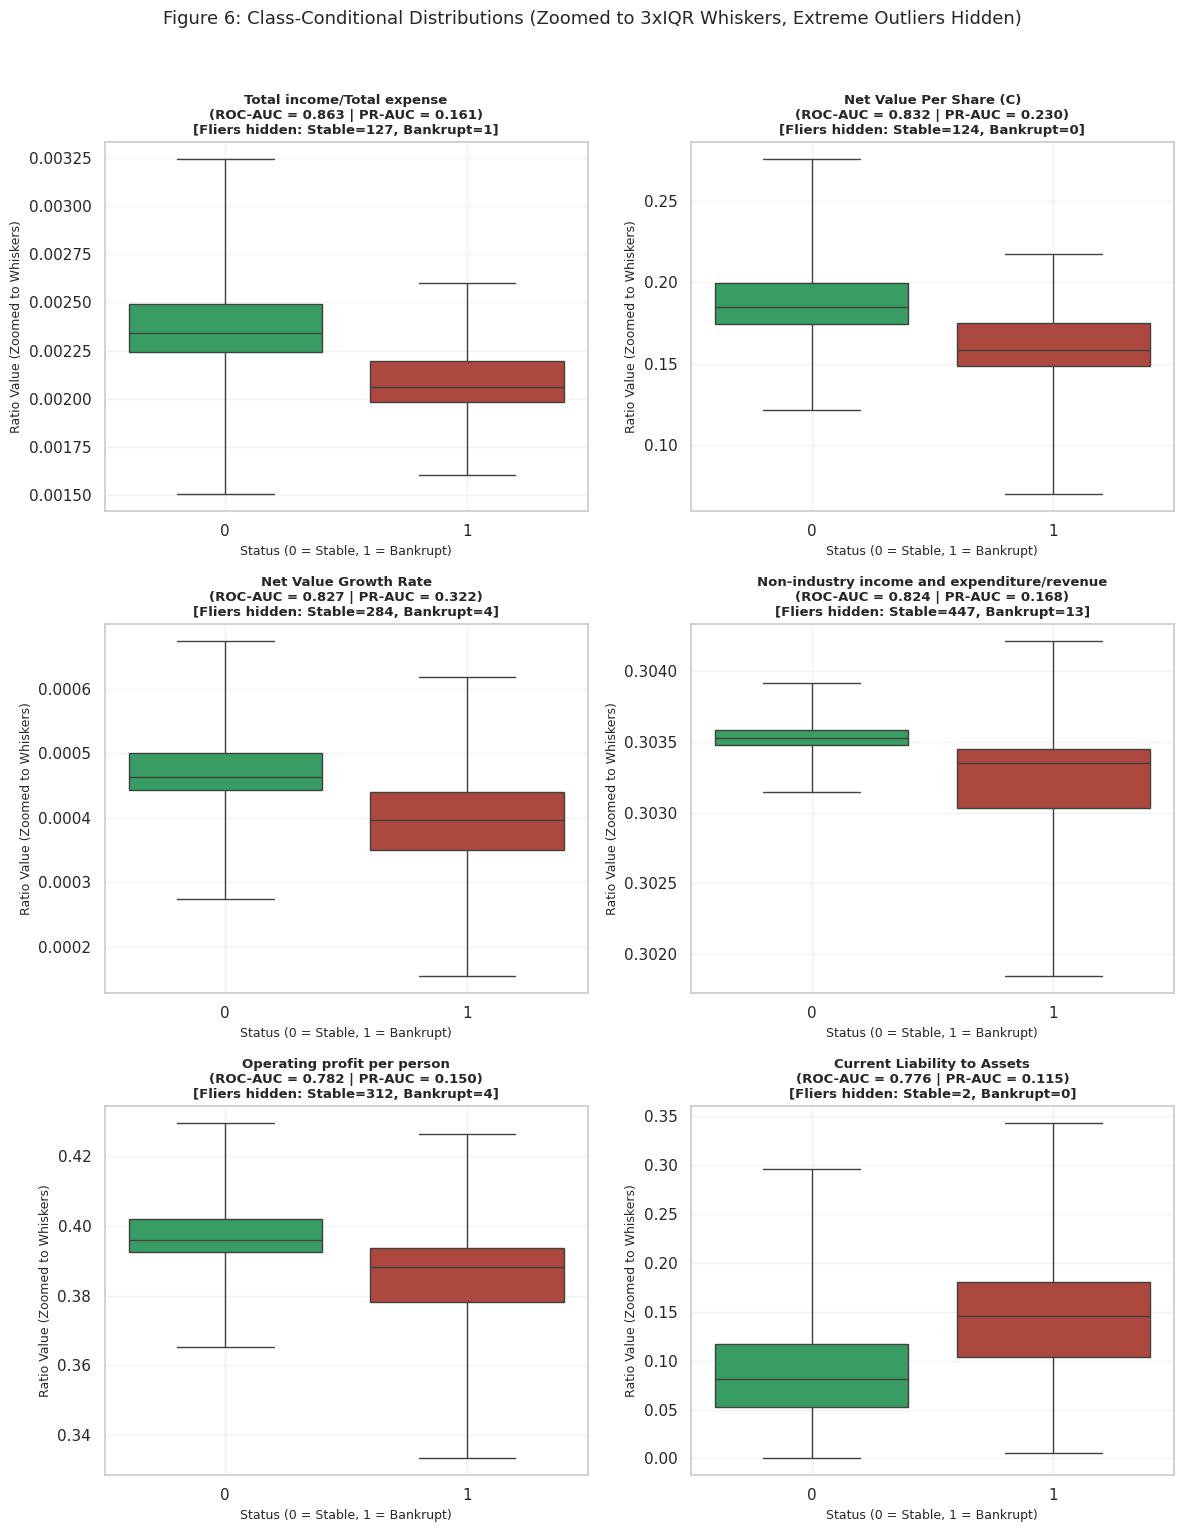

In [14]:
# 1. Predictive screening computed strictly on the training partition (X_train_reduced, y_train)
# Methodological Note:
# ROC-AUC evaluates ranking across all thresholds, but can present an overly optimistic view under severe class imbalance.
# Average Precision (PR-AUC / PRAUC) evaluates the precision-recall trade-off and focuses directly on the minority positive class.
screening_list = []

for col in X_train_reduced.columns:
    series = X_train_reduced[col]

    # Calculate ROC-AUC (direction-adjusted)
    roc = roc_auc_score(y_train, series)
    roc_adj = max(roc, 1.0 - roc)

    # Calculate PR-AUC (Precision-Recall Area under Curve, direction-adjusted)
    pr_pos = average_precision_score(y_train, series)
    pr_neg = average_precision_score(y_train, -series)
    pr_adj = max(pr_pos, pr_neg)

    screening_list.append({
        'Feature': col,
        'ROC_AUC': roc_adj,
        'PR_AUC': pr_adj,
        'Skewness': series.skew(),
        'Kurtosis': series.kurtosis()
    })

screening = pd.DataFrame(screening_list).sort_values(by='ROC_AUC', ascending=False).reset_index(drop=True)

# Baseline positive class prevalence on training set
baseline_prevalence = y_train.mean()

print("=" * 90)
print(f"PREDICTIVE SCREENING: TOP 15 FEATURES (TRAIN SET - Baseline PR-AUC = {baseline_prevalence:.4f})")
print("=" * 90)
print(screening.head(15).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Select top 6 features based on screening for in-depth visual assessment
top_6_features = screening['Feature'].head(6).tolist()

# Combine training data for class-conditional visual diagnostics
train_eda_df = pd.concat([y_train.reset_index(drop=True), X_train_reduced[top_6_features].reset_index(drop=True)], axis=1)

# Figure 6: Class-Conditional Discriminative Power (Stratified by Bankruptcy Status)
# Calibrated to Tukey's extended outer fences (3.0 * IQR, showfliers=False) to prevent extreme
# accounting anomalies from flattening the interquartile boxes while reporting hidden outliers.
fig_c, axes_c = plt.subplots(3, 2, figsize=(12, 15))
axes_c = axes_c.ravel()

for i, feat in enumerate(top_6_features):
    ax = axes_c[i]
    roc_val = screening.loc[screening['Feature'] == feat, 'ROC_AUC'].values[0]
    pr_val = screening.loc[screening['Feature'] == feat, 'PR_AUC'].values[0]

    # Calculate extreme outlier counts per class (Tukey's 3.0 * IQR outer fences)
    s0 = train_eda_df.loc[train_eda_df['Bankrupt?'] == 0, feat]
    s1 = train_eda_df.loc[train_eda_df['Bankrupt?'] == 1, feat]

    iqr0 = s0.quantile(0.75) - s0.quantile(0.25)
    fliers0 = int(((s0 < s0.quantile(0.25) - 3 * iqr0) | (s0 > s0.quantile(0.75) + 3 * iqr0)).sum())

    iqr1 = s1.quantile(0.75) - s1.quantile(0.25)
    fliers1 = int(((s1 < s1.quantile(0.25) - 3 * iqr1) | (s1 > s1.quantile(0.75) + 3 * iqr1)).sum())

    sns.boxplot(
        data=train_eda_df,
        x='Bankrupt?',
        y=feat,
        hue='Bankrupt?',
        palette={0: '#27ae60', 1: '#c0392b'},
        showfliers=False,
        whis=3.0,
        legend=False,
        ax=ax
    )
    ax.set_title(
        f"{feat}\n(ROC-AUC = {roc_val:.3f} | PR-AUC = {pr_val:.3f})\n[Fliers hidden: Stable={fliers0}, Bankrupt={fliers1}]",
        fontsize=9.5,
        fontweight='bold'
    )
    ax.set_xlabel('Status (0 = Stable, 1 = Bankrupt)', fontsize=9)
    ax.set_ylabel('Ratio Value (Zoomed to Whiskers)', fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Figure 6: Class-Conditional Distributions (Zoomed to 3xIQR Whiskers, Extreme Outliers Hidden)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Model-Based Clustering: Gaussian Mixture Models (GMM)

This section explores the latent structure of the financial data through model-based clustering.

The analysis includes:
- Standardization of the predictors
- Gaussian Mixture Models with different numbers of clusters
- Diagonal covariance structure
- Covariance regularization for numerical stability
- BIC-based evaluation of different values of K
- Selection of K = 4
- Assignment of observations to GMM clusters

The objective is to identify broad financial profiles among the companies while limiting the influence of numerical instability and isolated observations.

GMM MODEL SELECTION METRICS ACROSS K (TRAINING SET)
 K          BIC  Silhouette
 2  224413.5140      0.4390
 3  -61145.7663      0.3781
 4  -99287.9820      0.0945
 5 -136619.8655      0.0384
 6 -135152.7683      0.0457
 7 -150636.7276      0.0478
 8 -179861.4891      0.0205


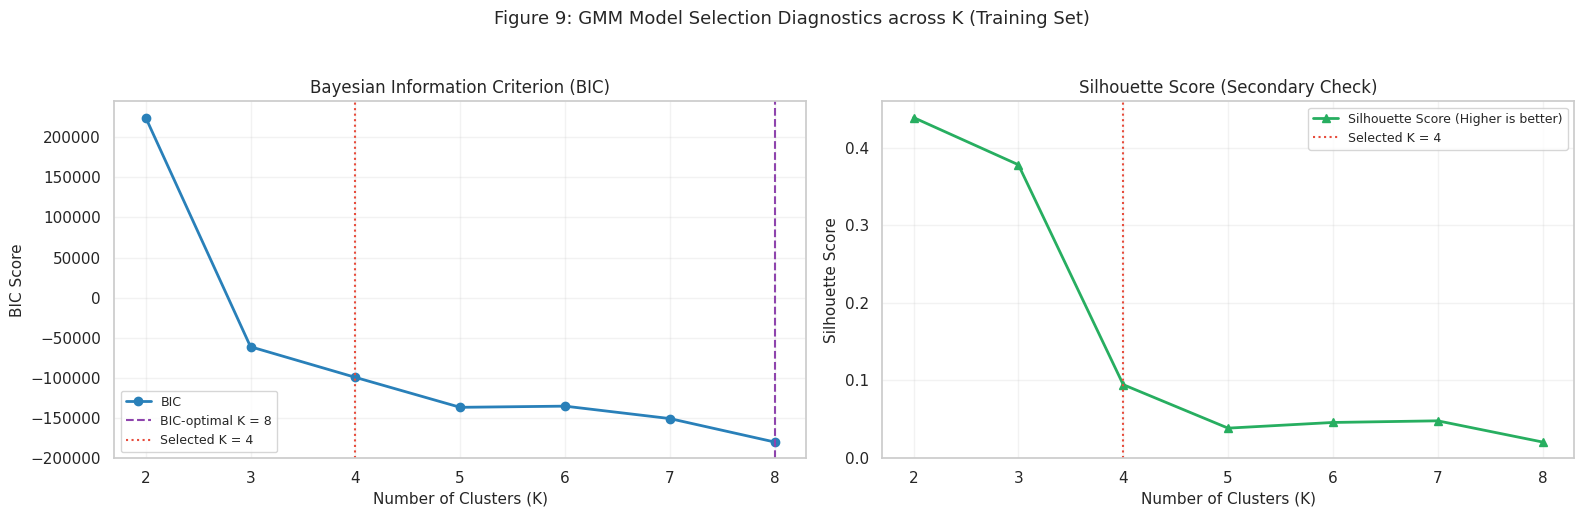


NOTE: BIC is minimized at K=8, not at the selected K=4. K=4 was selected as a compromise between statistical criteria (BIC) and economic interpretability of the resulting cluster profiles.

ECONOMIC INTERPRETATION OF GMM CLUSTERS (TRAINING SET)
 GMM_Cluster  Firm_Count  Bankruptcy_Count  Default_Rate
           0        1098                50        0.0455
           1         204                17        0.0833
           2        3875                84        0.0217
           3         278                25        0.0899


In [15]:
# 1. Feature scaling fit strictly on the training partition
scaler_gmm = StandardScaler()
X_train_gmm = scaler_gmm.fit_transform(X_train_reduced)
X_test_gmm = scaler_gmm.transform(X_test_reduced)

# 2. GMM Model Evaluation across K using information criteria and internal validation metrics
# Methodological Note on GMM vs. TCLUST:
# Classical GMM is a probabilistic generative model that assumes all data points belong to one of K Gaussian components.
# In the presence of heavy-tailed distributions and multivariate outliers, standard GMM exhibits sensitivity:
# it tends to create spurious micro-clusters with low variance to accommodate outliers.
# Model selection prioritizes BIC (directly tied to the mixture model likelihood, penalized for complexity),
# with Silhouette used only as a secondary geometric sanity check.
n_components_range = range(2, 9)
bic_scores = []
silhouette_scores = []
gmm_models = []

for k in n_components_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        n_init=10,
        random_state=42,
        reg_covar=1e-3
    )
    gmm.fit(X_train_gmm)

    train_preds = gmm.predict(X_train_gmm)

    bic_scores.append(gmm.bic(X_train_gmm))
    silhouette_scores.append(silhouette_score(X_train_gmm, train_preds))
    gmm_models.append(gmm)

# Tabular comparison of model selection metrics
gmm_selection_df = pd.DataFrame({
    'K': list(n_components_range),
    'BIC': bic_scores,
    'Silhouette': silhouette_scores
})

print("=" * 85)
print("GMM MODEL SELECTION METRICS ACROSS K (TRAINING SET)")
print("=" * 85)
print(gmm_selection_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Identify the K that minimizes BIC (statistical optimum)
bic_optimal_k = list(n_components_range)[int(np.argmin(bic_scores))]

# Figure 9: GMM Selection Criteria (BIC, Silhouette)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot BIC (Lower is better)
ax1.plot(n_components_range, bic_scores, marker='o', color='#2980b9', linewidth=2, label='BIC')
ax1.axvline(x=bic_optimal_k, color='#8e44ad', linestyle='--', linewidth=1.5, label=f'BIC-optimal K = {bic_optimal_k}')
ax1.axvline(x=4, color='#e74c3c', linestyle=':', linewidth=1.5, label='Selected K = 4')
ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('BIC Score', fontsize=11)
ax1.set_title('Bayesian Information Criterion (BIC)', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# Plot Silhouette (secondary geometric check)
ax2.plot(n_components_range, silhouette_scores, marker='^', color='#27ae60', linewidth=2, label='Silhouette Score (Higher is better)')
ax2.axvline(x=4, color='#e74c3c', linestyle=':', linewidth=1.5, label='Selected K = 4')
ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score (Secondary Check)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25)

plt.suptitle('Figure 9: GMM Model Selection Diagnostics across K (Training Set)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

# 3. Fit optimal GMM model (K=4) and apply to Train and Test partitions
best_k = 4
best_gmm = gmm_models[n_components_range.index(best_k)]

# Explicit justification of the K=4 choice relative to the BIC-optimal K
if bic_optimal_k != best_k:
    print(
        f"\nNOTE: BIC is minimized at K={bic_optimal_k}, not at the selected K={best_k}. "
        f"K={best_k} was selected as a compromise between statistical criteria (BIC) "
        f"and economic interpretability of the resulting cluster profiles."
    )
else:
    print(f"\nK={best_k} coincides with the BIC-optimal K, supporting the selection on statistical grounds.")

train_gmm_clusters = best_gmm.predict(X_train_gmm)
test_gmm_clusters = best_gmm.predict(X_test_gmm)

# Add cluster assignments to partitioned DataFrames
X_train_clustered = X_train_reduced.copy()
X_train_clustered['GMM_Cluster'] = train_gmm_clusters

X_test_clustered = X_test_reduced.copy()
X_test_clustered['GMM_Cluster'] = test_gmm_clusters

# 4. Economic Interpretation and Cluster Profile Analysis
# Compute class bankruptcy rate and key financial ratios per cluster
train_gmm_summary = X_train_clustered.copy()
train_gmm_summary['Bankrupt?'] = y_train.values

profile_cols = [
    'ROA(B) before interest and depreciation after tax',
    'Debt ratio %',
    'Current Ratio',
    'Quick Ratio'
]
valid_profile_cols = [c for c in profile_cols if c in train_gmm_summary.columns]

economic_profile = train_gmm_summary.groupby('GMM_Cluster').agg(
    Firm_Count=('Bankrupt?', 'count'),
    Bankruptcy_Count=('Bankrupt?', 'sum'),
    Default_Rate=('Bankrupt?', 'mean'),
    **{f'{c}_Median': (c, 'median') for c in valid_profile_cols}
).reset_index()

print("\n" + "=" * 95)
print("ECONOMIC INTERPRETATION OF GMM CLUSTERS (TRAINING SET)")
print("=" * 95)
print(economic_profile.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

## 7. Robust Clustering: TCLUST

This section applies robust clustering through TCLUST (Trimmed Clustering with Eigenvalue Restrictions).

The analysis includes:
- TCLUST estimation through `rpy2`
- 5% trimming of potentially influential observations
- Eigenvalue restrictions
- Identification of trimmed observations
- Assignment of observations to robust clusters

The objective is to obtain a clustering structure that is less sensitive to extreme observations and to identify observations that may distort the underlying financial profiles.

In [16]:
# 1. TCLUST Robust Clustering Execution (Strictly fit on training set)
# Methodological Note:
# - GMM: Assumes mixture of Gaussians over all points without trimming, making it vulnerable to masking and micro-clusters around extreme outliers.
# - TCLUST: Enforces robust trimmed clustering with trimming proportion alpha=0.05 and eigenvalue ratio
#   restriction restr.fact=12 (preventing cluster collapse / spurious singularities).
# Trimmed observations are treated as potentially influential points, not assumed to be noise or errors:
# an extreme financial profile may reflect genuine distress rather than a data artifact. The trimming
# below is therefore a sensitivity analysis, not a definitive data-cleaning step.
try:
    pandas2ri.activate()
    numpy2ri.activate()

    robjects.r('''
    if (!require("tclust", quietly=TRUE)) {
        install.packages("tclust", repos="https://cloud.r-project.org")
    }
    library(tclust)
    ''')

    # Pass scaled training features to R environment
    robjects.globalenv['X_train_r'] = pandas2ri.py2rpy(pd.DataFrame(X_train_gmm, columns=X_train_reduced.columns))
    robjects.globalenv['k_clusters'] = int(best_k)

    # Fit TCLUST model on training set
    r_code = """
    set.seed(42)
    tclust_fit <- tclust(as.matrix(X_train_r), k=k_clusters, alpha=0.05, restr.fact=12)
    list(
        cluster = tclust_fit$cluster,
        centers = tclust_fit$centers,
        cov     = tclust_fit$cov
    )
    """
    tclust_res = robjects.r(r_code)

    # Extract training assignments (0 denotes trimmed/potentially influential point in R -> convert to -1)
    train_tclust_raw = np.array(tclust_res.rx2('cluster'))
    train_tclust_raw[train_tclust_raw == 0] = -1

    # Extract fitted cluster centers (k clusters x p dimensions)
    cluster_centers = np.array(tclust_res.rx2('centers')).T

    # 2. Out-of-sample Assignment for Test Set (Preventing Data Leakage)
    # Test observations are assigned to the nearest cluster centroid in scaled space
    test_distances = cdist(X_test_gmm, cluster_centers, metric='euclidean')
    test_tclust_clusters = np.argmin(test_distances, axis=1) + 1  # 1-indexed to match R cluster labels

    # Store assignments in structured training and test containers
    X_train_clustered['TCLUST_Cluster'] = train_tclust_raw
    X_test_clustered['TCLUST_Cluster'] = test_tclust_clusters

    trimmed_train_count = np.sum(train_tclust_raw == -1)
    total_train_obs = len(X_train_gmm)

    print("=" * 80)
    print("TCLUST ROBUST CLUSTERING RESULTS (TRAINING SET, alpha=0.05)")
    print("=" * 80)
    print(f"Trimmed Observations (Potentially Influential, Label -1): {trimmed_train_count} / {total_train_obs} ({trimmed_train_count/total_train_obs:.2%})")
    print("\nTraining set cluster frequencies:")
    print(pd.Series(train_tclust_raw).value_counts().sort_index())
    print("\nTest set out-of-sample cluster frequencies (Assigned via Centroid Distance):")
    print(pd.Series(test_tclust_clusters).value_counts().sort_index())

    # 3. Quantitative Comparison: GMM vs TCLUST
    # Evaluate agreement on non-trimmed training observations
    non_trimmed_mask = train_tclust_raw != -1
    ari_score = adjusted_rand_score(train_gmm_clusters[non_trimmed_mask], train_tclust_raw[non_trimmed_mask])
    ami_score = adjusted_mutual_info_score(train_gmm_clusters[non_trimmed_mask], train_tclust_raw[non_trimmed_mask])

    print("\n" + "=" * 80)
    print("QUANTITATIVE COMPARISON: GMM vs. TCLUST (NON-TRIMMED OBSERVATIONS)")
    print("=" * 80)
    print(f"Adjusted Rand Index (ARI):            {ari_score:.4f}")
    print(f"Adjusted Mutual Information (AMI):    {ami_score:.4f}")

    contingency = pd.crosstab(
        pd.Series(train_gmm_clusters, name='GMM_Cluster'),
        pd.Series(train_tclust_raw, name='TCLUST_Cluster')
    )
    print("\nContingency Matrix (GMM vs TCLUST):")
    print(contingency.to_string())

    # 4. Economic Interpretation of TCLUST Clusters (Training Set)
    train_tclust_summary = X_train_reduced.copy()
    train_tclust_summary['TCLUST_Cluster'] = train_tclust_raw
    train_tclust_summary['Bankrupt?'] = y_train.values

    tclust_economic_profile = train_tclust_summary.groupby('TCLUST_Cluster').agg(
        Firm_Count=('Bankrupt?', 'count'),
        Bankruptcy_Count=('Bankrupt?', 'sum'),
        Default_Rate=('Bankrupt?', 'mean'),
        **{f'{c}_Median': (c, 'median') for c in valid_profile_cols}
    ).reset_index()

    print("\n" + "=" * 95)
    print("ECONOMIC INTERPRETATION OF TCLUST CLUSTERS (TRAINING SET)")
    print("=" * 95)
    print(tclust_economic_profile.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # 5. Sensitivity Analysis of the Trimming Proportion (alpha)
    # Checks whether the fraction of trimmed observations and the resulting default-rate
    # profile are stable across alternative trimming levels, rather than an artifact of alpha=0.05.
    alpha_grid = [0.03, 0.05, 0.10]
    alpha_sensitivity = []

    for a in alpha_grid:
        robjects.globalenv['alpha_val'] = float(a)
        r_code_alpha = """
        set.seed(42)
        tclust_fit_a <- tclust(as.matrix(X_train_r), k=k_clusters, alpha=alpha_val, restr.fact=12)
        tclust_fit_a$cluster
        """
        cluster_a = np.array(robjects.r(r_code_alpha))
        cluster_a[cluster_a == 0] = -1

        trimmed_a = np.sum(cluster_a == -1)
        default_rate_trimmed = y_train.values[cluster_a == -1].mean() if trimmed_a > 0 else np.nan
        default_rate_kept = y_train.values[cluster_a != -1].mean()

        alpha_sensitivity.append({
            'Alpha': a,
            'Trimmed_Count': trimmed_a,
            'Trimmed_Pct': trimmed_a / total_train_obs,
            'Default_Rate_Trimmed': default_rate_trimmed,
            'Default_Rate_Kept': default_rate_kept
        })

    alpha_sensitivity_df = pd.DataFrame(alpha_sensitivity)

    print("\n" + "=" * 95)
    print("SENSITIVITY ANALYSIS: TRIMMING PROPORTION (alpha)")
    print("=" * 95)
    print(alpha_sensitivity_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print("\nNote: results at alpha=0.05 above remain the reference configuration used downstream.")

except Exception as e:
    print(f"rpy2 / TCLUST execution error: {e}")

TCLUST ROBUST CLUSTERING RESULTS (TRAINING SET, alpha=0.05)
Trimmed Observations (Potentially Influential, Label -1): 273 / 5455 (5.00%)

Training set cluster frequencies:
-1.0     273
 1.0    1734
 2.0    1466
 3.0    1369
 4.0     613
Name: count, dtype: int64

Test set out-of-sample cluster frequencies (Assigned via Centroid Distance):
1    456
2    448
3    328
4    132
Name: count, dtype: int64

QUANTITATIVE COMPARISON: GMM vs. TCLUST (NON-TRIMMED OBSERVATIONS)
Adjusted Rand Index (ARI):            0.1489
Adjusted Mutual Information (AMI):    0.1996

Contingency Matrix (GMM vs TCLUST):
TCLUST_Cluster  -1.0   1.0   2.0   3.0   4.0
GMM_Cluster                                 
0                 79    74   752    40   153
1                137     8     0    11    48
2                  7  1639   668  1301   260
3                 50    13    46    17   152

ECONOMIC INTERPRETATION OF TCLUST CLUSTERS (TRAINING SET)
 TCLUST_Cluster  Firm_Count  Bankruptcy_Count  Default_Rate
        -1.00

# PART III — Predictive modeling (Logistic Mixed-Effects Model)


## 8. GLMM training

This section estimates the final classification model using a Logistic Mixed-Effects Model (GLMM).

The analysis includes:
- Selection of the top 5 most discriminative financial features based on the previous PR-AUC screening
- Robust Standardization of the selected features
- Exclusion of severe outliers (Cluster -1) identified by TCLUST to ensure impartial trimming
- Model estimation using `lme4` (glmer) via `rpy2`, with TCLUST assignment as the Random Intercept
- Calculation of the Variance Partition Coefficient (VPC)

The objective is to provide a statistically sound and robust predictive model that inherently
manages unobserved heterogeneity and leverage points without relying on artificial power transformations (e.g. Yeo-Johnson).

In [17]:
# 1. Feature Selection from Univariate Screening
# Select the top 5 features identified in the Predictive Screening (Section 5)
top_5_features = screening['Feature'].head(5).tolist()

# 2. Data Preparation and Robust Scaling
# We use RobustScaler to mitigate the effect of extreme intra-cluster anomalies
scaler_glmm = RobustScaler()
X_train_glmm = pd.DataFrame(
    scaler_glmm.fit_transform(X_train_clustered[top_5_features]),
    columns=top_5_features,
    index=X_train_clustered.index
)

train_glmm_df = X_train_glmm.copy()
train_glmm_df['Bankrupt'] = y_train.values
train_glmm_df['TCLUST_Cluster'] = X_train_clustered['TCLUST_Cluster'].values

# IMPARTIAL TRIMMING: Remove observations flagged as severe outliers by TCLUST (Cluster == -1)
# This guarantees that our predictive model learns only from coherent financial profiles
train_glmm_df_clean = train_glmm_df[train_glmm_df['TCLUST_Cluster'] != -1].copy()

# Rename columns to avoid R syntax errors in formulas (e.g. spaces, symbols)
safe_names = [f"F{i}" for i in range(1, 6)]
rename_dict = dict(zip(top_5_features, safe_names))
train_glmm_df_clean.rename(columns=rename_dict, inplace=True)

print("=" * 80)
print(f"TRAINING GLMM ON CLEANED DATA (Excluded {np.sum(train_glmm_df['TCLUST_Cluster'] == -1)} severe outliers identified by TCLUST)")
print("=" * 80)
for orig_name, safe_name in rename_dict.items():
    print(f"{safe_name}: {orig_name}")

# 3. Model Estimation via R's lme4::glmer
pandas2ri.activate()
robjects.globalenv['train_data'] = pandas2ri.py2rpy(train_glmm_df_clean)

r_code_glmm = """
if (!require("lme4", quietly=TRUE)) {
    install.packages("lme4", repos="https://cloud.r-project.org")
}
library(lme4)

# Dynamically construct formula: Bankrupt ~ F1 + F2 + F3 + F4 + F5 + (1 | TCLUST_Cluster)
feature_terms <- paste(paste0("F", 1:5), collapse=" + ")
formula_str <- paste("Bankrupt ~", feature_terms, "+ (1 | TCLUST_Cluster)")

# Fit the Logistic Mixed-Effects Model (Random Intercept per TCLUST profile)
glmm_model <- glmer(as.formula(formula_str), data=train_data, family=binomial, control=glmerControl(optimizer="bobyqa"))

# Extract Random Effect Variance and Fixed Effects Coefficients
random_variance <- as.data.frame(VarCorr(glmm_model))$vcov[1]
fixed_effects <- fixef(glmm_model)

# Print Summary directly from R
print(summary(glmm_model))

list(
    rand_var = random_variance,
    fixed = fixed_effects
)
"""

try:
    glmm_res = robjects.r(r_code_glmm)
    rand_var = glmm_res.rx2('rand_var')[0]

    # 4. Variance Partition Coefficient (VPC)
    # The variance of the standard logistic distribution is pi^2 / 3
    vpc = rand_var / (rand_var + (np.pi**2 / 3))

    print("\n" + "=" * 80)
    print("LOGISTIC MIXED EFFECTS MODEL (GLMM) RESULTS")
    print("=" * 80)
    print(f"Random Intercept Variance (sigma^2_b): {rand_var:.4f}")
    print(f"Variance Partition Coefficient (VPC):  {vpc:.2%}")
    print("-" * 80)
    print(f"Interpretation: {vpc:.2%} of the unexplained variability in bankruptcy risk")
    print("is due to the underlying financial profile (TCLUST Cluster) of the company.")
    print("=" * 80)

except Exception as e:
    print(f"GLMM (lme4::glmer) fitting failed: {e}")

# 5. Out-of-Sample Predictions for Part IV Validation
# Prepare Test Data
X_test_glmm = pd.DataFrame(
    scaler_glmm.transform(X_test_clustered[top_5_features]),
    columns=top_5_features,
    index=X_test_clustered.index
)
test_glmm_df = X_test_glmm.copy()
test_glmm_df['TCLUST_Cluster'] = X_test_clustered['TCLUST_Cluster'].values
test_glmm_df.rename(columns=rename_dict, inplace=True)

robjects.globalenv['test_data'] = pandas2ri.py2rpy(test_glmm_df)

r_code_predict = """
# Predict probabilities on test set. allow.new.levels=TRUE handles test companies
# assigned to the noise cluster (-1) that were not seen during training.
pred_probs <- predict(glmm_model, newdata = test_data, type = "response", allow.new.levels = TRUE)
pred_probs  # <-- Aggiunto questo!
"""
try:
    pred_glmm_probs = np.array(robjects.r(r_code_predict))
    pred_fe_probs = pred_glmm_probs # For backward compatibility with Part IV metrics
except Exception as e:
    print(f"GLMM Prediction failed: {e}")

TRAINING GLMM ON CLEANED DATA (Excluded 273 severe outliers identified by TCLUST)
F1: Total income/Total expense
F2: Net Value Per Share (C)
F3: Net Value Growth Rate
F4: Non-industry income and expenditure/revenue
F5: Operating profit per person
Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: Bankrupt ~ F1 + F2 + F3 + F4 + F5 + (1 | TCLUST_Cluster)
   Data: train_data
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
   1036.6    1082.5    -511.3    1022.6      5175 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.3870 -0.1525 -0.0964 -0.0488 22.8792 

Random effects:
 Groups         Name        Variance Std.Dev.
 TCLUST_Cluster (Intercept) 0.04152  0.2038  
Number of obs: 5182, groups:  TCLUST_Cluster, 4

Fixed effects:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.287075   0.178181 -24.060  < 2e-16 ***
F1          -0

# PART IV — Model validation and robustness - Classification and decision making



## 9. Cluster-Specific ROC/AUC Diagnostics

This section evaluates whether the predictive performance of the cluster-based model is consistent across the different TCLUST financial profiles.

The analysis includes:
- ROC curves for individual clusters
- Cluster-specific AUC values
- Global ROC curve
- Comparison between cluster-specific and global predictive performance

The objective is to determine whether the model performs consistently across different groups of companies.

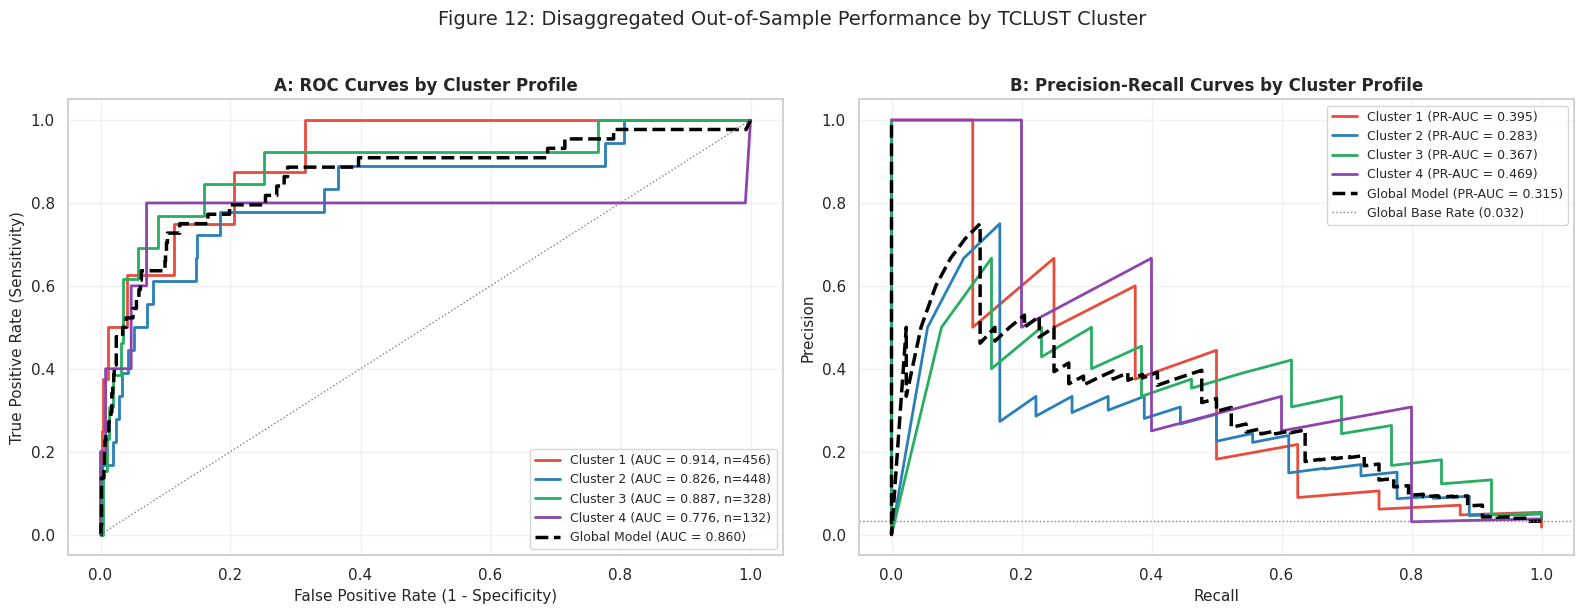

DISAGGREGATED PERFORMANCE DIAGNOSTICS BY FIRM CLUSTER (TEST SET)
Cluster_ID  Observations  Bankrupt_Count  Default_Rate  ROC_AUC  PR_AUC  Brier_Score
 Cluster 1           456               8        0.0175   0.9135  0.3948       0.0141
 Cluster 2           448              18        0.0402   0.8264  0.2829       0.0348
 Cluster 3           328              13        0.0396   0.8869  0.3666       0.0316
 Cluster 4           132               5        0.0379   0.7756  0.4691       0.0287


In [18]:
# 1. Cluster-Stratified Out-of-Sample Performance Evaluation
# Methodological Note:
# Aggregate metrics can mask significant performance heterogeneity across firm typologies.
# Evaluating both ROC-AUC and PR-AUC at the cluster level reveals whether model discrimination
# holds uniformly or degrades in specific financial profiles (e.g., highly distressed vs. liquid firms).
test_clusters = X_test_clustered['TCLUST_Cluster'].values
unique_test_clusters = np.unique(test_clusters)

colors = ['#e74c3c', '#2980b9', '#27ae60', '#8e44ad', '#d35400']
cluster_color_map = {c_id: colors[i % len(colors)] for i, c_id in enumerate(unique_test_clusters)}

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(16, 6))

cluster_diagnostics = []

for c_id in sorted(unique_test_clusters):
    mask = (test_clusters == c_id)
    n_obs = int(mask.sum())
    n_bankrupt = int(y_test[mask].sum())
    default_rate = y_test[mask].mean()

    y_true_c = y_test[mask]
    y_prob_c = pred_fe_probs[mask]

    # Evaluate performance if both classes are present in the cluster partition
    if len(np.unique(y_true_c)) > 1:
        auc_c = roc_auc_score(y_true_c, y_prob_c)
        pr_c = average_precision_score(y_true_c, y_prob_c)
        brier_c = brier_score_loss(y_true_c, y_prob_c)

        cluster_diagnostics.append({
            'Cluster_ID': f"Cluster {c_id}" if c_id != -1 else "Cluster -1 (Potentially Influential)",
            'Observations': n_obs,
            'Bankrupt_Count': n_bankrupt,
            'Default_Rate': default_rate,
            'ROC_AUC': auc_c,
            'PR_AUC': pr_c,
            'Brier_Score': brier_c
        })

        # Plot ROC curve for cluster
        fpr_c, tpr_c, _ = roc_curve(y_true_c, y_prob_c)
        ax_roc.plot(
            fpr_c, tpr_c,
            color=cluster_color_map[c_id],
            linewidth=2,
            label=f"Cluster {c_id} (AUC = {auc_c:.3f}, n={n_obs})"
        )

        # Plot Precision-Recall curve for cluster
        prec_c, rec_c, _ = precision_recall_curve(y_true_c, y_prob_c)
        ax_pr.plot(
            rec_c, prec_c,
            color=cluster_color_map[c_id],
            linewidth=2,
            label=f"Cluster {c_id} (PR-AUC = {pr_c:.3f})"
        )
    else:
        # Single-class cluster partition
        cluster_diagnostics.append({
            'Cluster_ID': f"Cluster {c_id}" if c_id != -1 else "Cluster -1 (Potentially Influential)",
            'Observations': n_obs,
            'Bankrupt_Count': n_bankrupt,
            'Default_Rate': default_rate,
            'ROC_AUC': np.nan,
            'PR_AUC': np.nan,
            'Brier_Score': brier_score_loss(y_true_c, y_prob_c)
        })

# Global out-of-sample benchmark curves
fpr_glob, tpr_glob, _ = roc_curve(y_test, pred_fe_probs)
glob_auc = roc_auc_score(y_test, pred_fe_probs)
ax_roc.plot(fpr_glob, tpr_glob, color='black', linestyle='--', linewidth=2.5, label=f'Global Model (AUC = {glob_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1)

ax_roc.set_title('A: ROC Curves by Cluster Profile', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax_roc.set_ylabel('True Positive Rate (Sensitivity)', fontsize=11)
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.grid(True, alpha=0.25)

# Global Precision-Recall curve
prec_glob, rec_glob, _ = precision_recall_curve(y_test, pred_fe_probs)
glob_pr = average_precision_score(y_test, pred_fe_probs)
ax_pr.plot(rec_glob, prec_glob, color='black', linestyle='--', linewidth=2.5, label=f'Global Model (PR-AUC = {glob_pr:.3f})')
ax_pr.axhline(y_test.mean(), color='gray', linestyle=':', linewidth=1, label=f'Global Base Rate ({y_test.mean():.3f})')

ax_pr.set_title('B: Precision-Recall Curves by Cluster Profile', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall', fontsize=11)
ax_pr.set_ylabel('Precision', fontsize=11)
ax_pr.legend(loc='upper right', fontsize=9)
ax_pr.grid(True, alpha=0.25)

plt.suptitle('Figure 12: Disaggregated Out-of-Sample Performance by TCLUST Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Tabular Performance Disaggregation
cluster_summary_df = pd.DataFrame(cluster_diagnostics)

print("=" * 95)
print("DISAGGREGATED PERFORMANCE DIAGNOSTICS BY FIRM CLUSTER (TEST SET)")
print("=" * 95)
print(cluster_summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

## 10. Bootstrap Validation of ROC-AUC

This section assesses the statistical uncertainty associated with the estimated ROC-AUC.

The analysis includes:
- Bootstrap resampling
- 1,000 bootstrap iterations
- Bootstrap distribution of ROC-AUC
- 95% bootstrap confidence interval
- Comparison between the point estimate and its confidence interval

The objective is to evaluate the stability and uncertainty of the model's predictive performance.

OUT-OF-SAMPLE BOOTSTRAP INFERENCE SUMMARY (B = 2000 valid resamples)
     Metric  Point_Estimate  Bootstrap_Mean  Bootstrap_SE  CI_2.5%  CI_97.5%
    ROC-AUC          0.8598          0.8587        0.0354   0.7851    0.9221
     PR-AUC          0.3150          0.3282        0.0707   0.1979    0.4727
Brier Score          0.0265          0.0265        0.0036   0.0200    0.0343


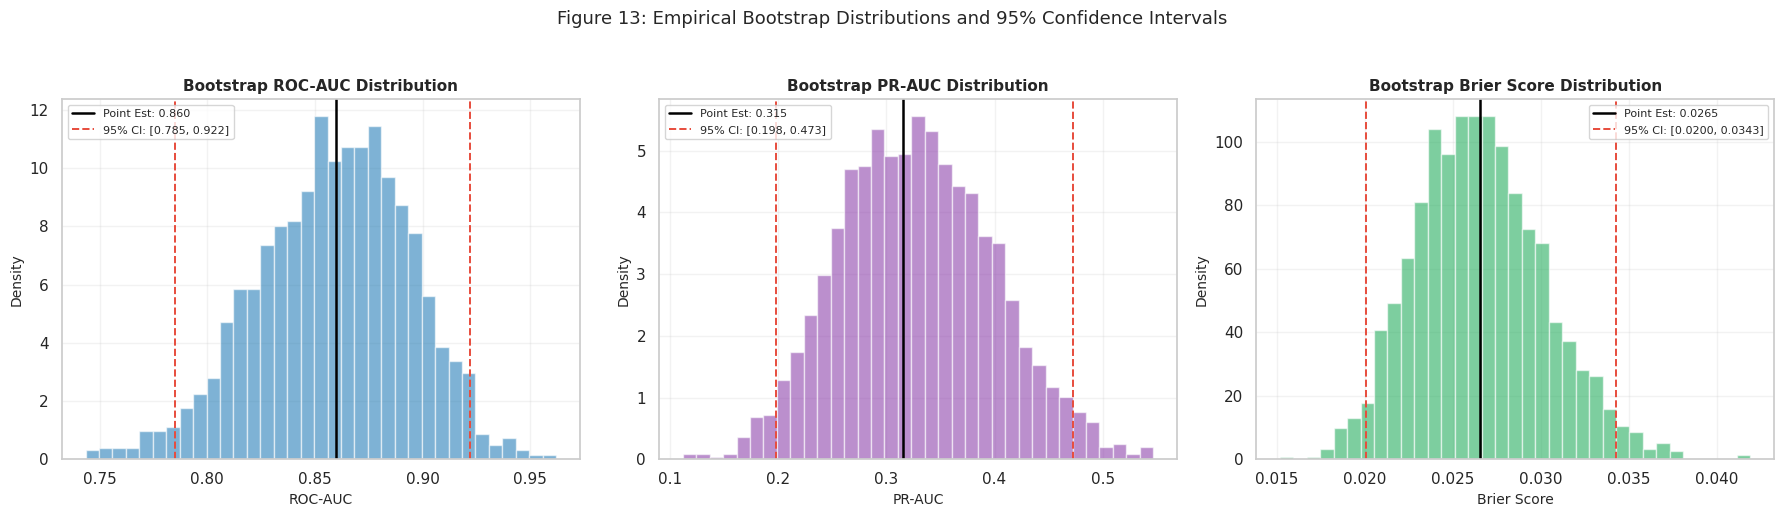

In [19]:
# 1. Non-Parametric Test Set Bootstrap Inference (Item 9, 26)
# Methodological Note on Bootstrap Validation:
# Out-of-sample point estimates are subject to sampling variability, especially under high class imbalance.
# An empirical non-parametric bootstrap (B = 2000 resamples with replacement) is conducted on the holdout test set
# to compute standard errors and 95% empirical percentile confidence intervals for ROC-AUC, PR-AUC, and Brier score.
np.random.seed(42)
B = 2000
n_test = len(y_test)

boot_roc = []
boot_pr = []
boot_brier = []

y_test_array = y_test.values if isinstance(y_test, pd.Series) else y_test

for b in range(B):
    boot_idx = np.random.choice(n_test, size=n_test, replace=True)
    y_boot = y_test_array[boot_idx]
    p_boot = pred_fe_probs[boot_idx]

    # Evaluate metrics only if resample contains both positive and negative cases
    if len(np.unique(y_boot)) > 1:
        boot_roc.append(roc_auc_score(y_boot, p_boot))
        boot_pr.append(average_precision_score(y_boot, p_boot))
        boot_brier.append(brier_score_loss(y_boot, p_boot))

boot_roc = np.array(boot_roc)
boot_pr = np.array(boot_pr)
boot_brier = np.array(boot_brier)

# Compute point estimates and 95% percentile confidence intervals [2.5%, 97.5%]
point_roc = roc_auc_score(y_test, pred_fe_probs)
point_pr = average_precision_score(y_test, pred_fe_probs)
point_brier = brier_score_loss(y_test, pred_fe_probs)

ci_roc = (np.percentile(boot_roc, 2.5), np.percentile(boot_roc, 97.5))
ci_pr = (np.percentile(boot_pr, 2.5), np.percentile(boot_pr, 97.5))
ci_brier = (np.percentile(boot_brier, 2.5), np.percentile(boot_brier, 97.5))

bootstrap_summary = pd.DataFrame({
    'Metric': ['ROC-AUC', 'PR-AUC', 'Brier Score'],
    'Point_Estimate': [point_roc, point_pr, point_brier],
    'Bootstrap_Mean': [boot_roc.mean(), boot_pr.mean(), boot_brier.mean()],
    'Bootstrap_SE': [boot_roc.std(), boot_pr.std(), boot_brier.std()],
    'CI_2.5%': [ci_roc[0], ci_pr[0], ci_brier[0]],
    'CI_97.5%': [ci_roc[1], ci_pr[1], ci_brier[1]]
})

print("=" * 90)
print(f"OUT-OF-SAMPLE BOOTSTRAP INFERENCE SUMMARY (B = {len(boot_roc)} valid resamples)")
print("=" * 90)
print(bootstrap_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 2. Visualizing Bootstrap Sampling Distributions (Item 29, 30)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: ROC-AUC Distribution
ax1.hist(boot_roc, bins=35, density=True, alpha=0.6, color='#2980b9', edgecolor='white')
ax1.axvline(point_roc, color='black', linewidth=1.8, label=f'Point Est: {point_roc:.3f}')
ax1.axvline(ci_roc[0], color='#e74c3c', linestyle='--', linewidth=1.4, label=f'95% CI: [{ci_roc[0]:.3f}, {ci_roc[1]:.3f}]')
ax1.axvline(ci_roc[1], color='#e74c3c', linestyle='--', linewidth=1.4)
ax1.set_title('Bootstrap ROC-AUC Distribution', fontsize=11, fontweight='bold')
ax1.set_xlabel('ROC-AUC', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.25)

# Subplot 2: PR-AUC Distribution
ax2.hist(boot_pr, bins=35, density=True, alpha=0.6, color='#8e44ad', edgecolor='white')
ax2.axvline(point_pr, color='black', linewidth=1.8, label=f'Point Est: {point_pr:.3f}')
ax2.axvline(ci_pr[0], color='#e74c3c', linestyle='--', linewidth=1.4, label=f'95% CI: [{ci_pr[0]:.3f}, {ci_pr[1]:.3f}]')
ax2.axvline(ci_pr[1], color='#e74c3c', linestyle='--', linewidth=1.4)
ax2.set_title('Bootstrap PR-AUC Distribution', fontsize=11, fontweight='bold')
ax2.set_xlabel('PR-AUC', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True, alpha=0.25)

# Subplot 3: Brier Score Distribution
ax3.hist(boot_brier, bins=35, density=True, alpha=0.6, color='#27ae60', edgecolor='white')
ax3.axvline(point_brier, color='black', linewidth=1.8, label=f'Point Est: {point_brier:.4f}')
ax3.axvline(ci_brier[0], color='#e74c3c', linestyle='--', linewidth=1.4, label=f'95% CI: [{ci_brier[0]:.4f}, {ci_brier[1]:.4f}]')
ax3.axvline(ci_brier[1], color='#e74c3c', linestyle='--', linewidth=1.4)
ax3.set_title('Bootstrap Brier Score Distribution', fontsize=11, fontweight='bold')
ax3.set_xlabel('Brier Score', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(True, alpha=0.25)

plt.suptitle('Figure 13: Empirical Bootstrap Distributions and 95% Confidence Intervals', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 11. Impact of Outlier Removal: TCLUST vs. Contaminated Data

This section evaluates the impact of robust outlier removal on predictive performance.

The analysis compares:
- Model performance on the original test set
- Model performance on the TCLUST-cleaned test set
- ROC-AUC values
- 95% bootstrap confidence intervals
- Bootstrap distributions of the AUC

The objective is to determine whether removing observations identified as outliers by TCLUST improves the predictive performance of the model.

TRIMMING SENSITIVITY ASSESSMENT: FULL SAMPLE VS. NON-TRIMMED TEST EVALUATION
            Dataset Partition  ROC_AUC   ROC_AUC_95%_CI   PR_AUC    PR_AUC_95%_CI  Brier_Score
       Full Test Set (n=1364) 0.859771 [0.7837, 0.9237] 0.314974 [0.1968, 0.4781]     0.026538
Non-Trimmed Test Set (n=1364) 0.859771 [0.7858, 0.9209] 0.314974 [0.2004, 0.4782]     0.026538

Net ROC-AUC Difference (Non-Trimmed - Full): +0.0000
Net PR-AUC Difference (Non-Trimmed - Full):  +0.0000

Note: a small or non-significant difference indicates TCLUST trimming does not materially
change predictive performance on this test set; a large difference should prompt inspection
of the trimmed observations rather than automatic removal.


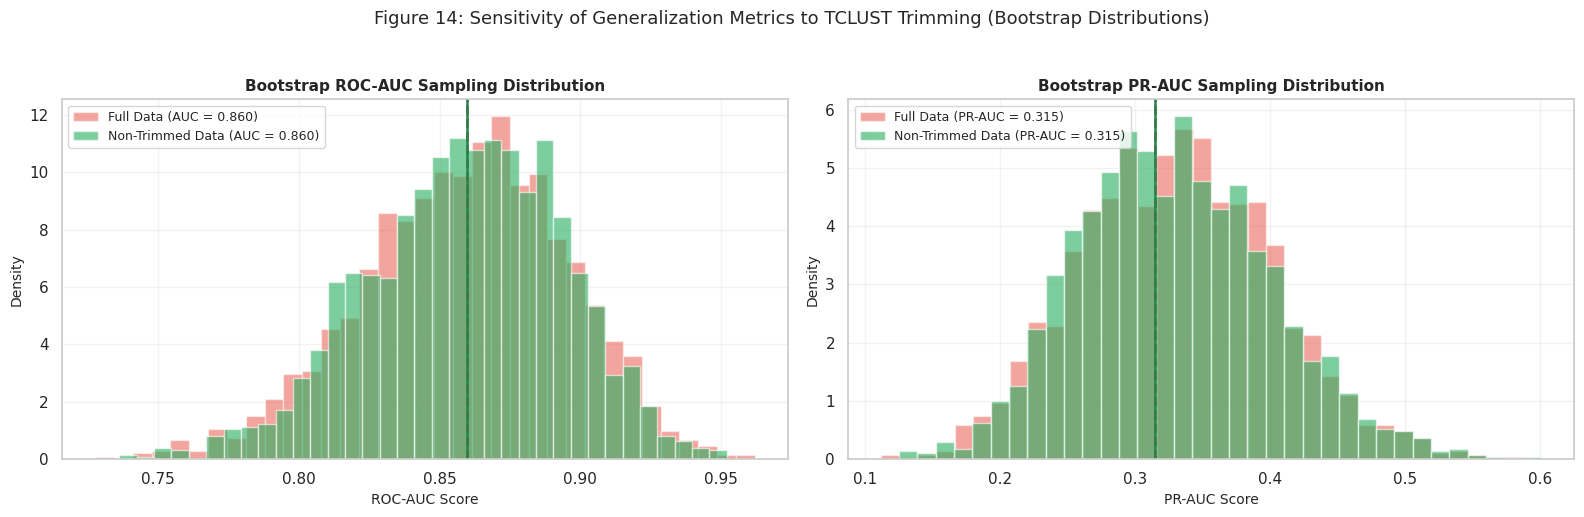

In [20]:
# 1. Benchmark Construction: Full Test Sample vs. Trimming Sensitivity Evaluation
# In the GLMM pipeline, pred_all_probs contains the out-of-sample predictions for the full test set.
pred_all_probs = pred_fe_probs

# Predictions on Non-Trimmed Test Partition (excluding Cluster -1, potentially influential points)
non_trimmed_test_mask = (X_test_clustered['TCLUST_Cluster'] != -1).values
y_test_clean = y_test[non_trimmed_test_mask]
pred_clean_probs = pred_all_probs[non_trimmed_test_mask]

# 2. Multi-Metric Out-of-Sample Performance Comparison
auc_all = roc_auc_score(y_test, pred_all_probs)
pr_all = average_precision_score(y_test, pred_all_probs)
brier_all = brier_score_loss(y_test, pred_all_probs)

auc_clean = roc_auc_score(y_test_clean, pred_clean_probs)
pr_clean = average_precision_score(y_test_clean, pred_clean_probs)
brier_clean = brier_score_loss(y_test_clean, pred_clean_probs)

# 3. Paired Non-Parametric Bootstrap Inference (B = 2000)
np.random.seed(42)
B = 2000
n_all = len(y_test)
n_clean = len(y_test_clean)

boot_auc_all = []
boot_pr_all = []
boot_auc_clean = []
boot_pr_clean = []

y_test_array = y_test.values
y_test_clean_array = y_test_clean.values

for b in range(B):
    # Resample full test set
    idx_all = np.random.choice(n_all, size=n_all, replace=True)
    y_b_all = y_test_array[idx_all]
    p_b_all = pred_all_probs[idx_all]

    if len(np.unique(y_b_all)) > 1:
        boot_auc_all.append(roc_auc_score(y_b_all, p_b_all))
        boot_pr_all.append(average_precision_score(y_b_all, p_b_all))

    # Resample non-trimmed test set
    idx_clean = np.random.choice(n_clean, size=n_clean, replace=True)
    y_b_clean = y_test_clean_array[idx_clean]
    p_b_clean = pred_clean_probs[idx_clean]

    if len(np.unique(y_b_clean)) > 1:
        boot_auc_clean.append(roc_auc_score(y_b_clean, p_b_clean))
        boot_pr_clean.append(average_precision_score(y_b_clean, p_b_clean))

# Calculate empirical 95% confidence intervals
ci_auc_all = (np.percentile(boot_auc_all, 2.5), np.percentile(boot_auc_all, 97.5))
ci_pr_all = (np.percentile(boot_pr_all, 2.5), np.percentile(boot_pr_all, 97.5))

ci_auc_clean = (np.percentile(boot_auc_clean, 2.5), np.percentile(boot_auc_clean, 97.5))
ci_pr_clean = (np.percentile(boot_pr_clean, 2.5), np.percentile(boot_pr_clean, 97.5))

# Summary Comparison Table
outlier_impact_table = pd.DataFrame([
    {
        'Dataset Partition': f'Full Test Set (n={n_all})',
        'ROC_AUC': auc_all,
        'ROC_AUC_95%_CI': f"[{ci_auc_all[0]:.4f}, {ci_auc_all[1]:.4f}]",
        'PR_AUC': pr_all,
        'PR_AUC_95%_CI': f"[{ci_pr_all[0]:.4f}, {ci_pr_all[1]:.4f}]",
        'Brier_Score': brier_all
    },
    {
        'Dataset Partition': f'Non-Trimmed Test Set (n={n_clean})',
        'ROC_AUC': auc_clean,
        'ROC_AUC_95%_CI': f"[{ci_auc_clean[0]:.4f}, {ci_auc_clean[1]:.4f}]",
        'PR_AUC': pr_clean,
        'PR_AUC_95%_CI': f"[{ci_pr_clean[0]:.4f}, {ci_pr_clean[1]:.4f}]",
        'Brier_Score': brier_clean
    }
])

print("=" * 105)
print("TRIMMING SENSITIVITY ASSESSMENT: FULL SAMPLE VS. NON-TRIMMED TEST EVALUATION")
print("=" * 105)
print(outlier_impact_table.to_string(index=False))
print(f"\nNet ROC-AUC Difference (Non-Trimmed - Full): {auc_clean - auc_all:+.4f}")
print(f"Net PR-AUC Difference (Non-Trimmed - Full):  {pr_clean - pr_all:+.4f}")
print("\nNote: a small or non-significant difference indicates TCLUST trimming does not materially")
print("change predictive performance on this test set; a large difference should prompt inspection")
print("of the trimmed observations rather than automatic removal.")

# 4. Comparative Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Bootstrap ROC-AUC Comparison
ax1.hist(boot_auc_all, bins=35, density=True, color='#e74c3c', alpha=0.5, label=f'Full Data (AUC = {auc_all:.3f})', edgecolor='white')
ax1.hist(boot_auc_clean, bins=35, density=True, color='#27ae60', alpha=0.6, label=f'Non-Trimmed Data (AUC = {auc_clean:.3f})', edgecolor='white')
ax1.axvline(auc_all, color='#c0392b', linestyle='--', linewidth=1.8)
ax1.axvline(auc_clean, color='#1e8449', linestyle='-', linewidth=1.8)
ax1.set_title('Bootstrap ROC-AUC Sampling Distribution', fontsize=11, fontweight='bold')
ax1.set_xlabel('ROC-AUC Score', fontsize=10)
ax1.set_ylabel('Density', fontsize=10)
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.25)

# Panel 2: Bootstrap PR-AUC Comparison
ax2.hist(boot_pr_all, bins=35, density=True, color='#e74c3c', alpha=0.5, label=f'Full Data (PR-AUC = {pr_all:.3f})', edgecolor='white')
ax2.hist(boot_pr_clean, bins=35, density=True, color='#27ae60', alpha=0.6, label=f'Non-Trimmed Data (PR-AUC = {pr_clean:.3f})', edgecolor='white')
ax2.axvline(pr_all, color='#c0392b', linestyle='--', linewidth=1.8)
ax2.axvline(pr_clean, color='#1e8449', linestyle='-', linewidth=1.8)
ax2.set_title('Bootstrap PR-AUC Sampling Distribution', fontsize=11, fontweight='bold')
ax2.set_xlabel('PR-AUC Score', fontsize=10)
ax2.set_ylabel('Density', fontsize=10)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, alpha=0.25)

plt.suptitle('Figure 14: Sensitivity of Generalization Metrics to TCLUST Trimming (Bootstrap Distributions)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 12. Classification Threshold Optimization and Decision Analysis

This section evaluates the final GLMM model from a classification perspective.

The analysis includes:
- Evaluation at standard threshold (0.50)
- Optimal decision threshold selection via Youden's J statistic
- Confusion matrices and Classification Reports (Precision, Recall/Specificity, NPV, F1)
- Visual Confusion Matrices
- Comparative assessment of classification policies

The objective is to identify an appropriate decision threshold and evaluate the trade-off between correctly identifying bankrupt companies and generating false classifications.

CLASSIFICATION PERFORMANCE AT STANDARD THRESHOLD (0.50)
True Negatives (TN):  1313 | False Positives (FP):    7
False Negatives (FN):   38 | True Positives (TP):     6
Sensitivity (Recall): 0.1364 | Specificity: 0.9947 | Precision: 0.4615 | NPV: 0.9719 | F1: 0.2105
Training-derived Youden threshold: 0.0314

CLASSIFICATION PERFORMANCE AT TRAINING-DERIVED YOUDEN THRESHOLD (0.0314)
True Negatives (TN):  1074 | False Positives (FP):  246
False Negatives (FN):   10 | True Positives (TP):    34
Sensitivity (Recall): 0.7727 | Specificity: 0.8136 | Precision: 0.1214 | NPV: 0.9908 | F1: 0.2099

=== CONFUSION MATRIX (Optimal Threshold) ===
[[1074  246]
 [  10   34]]

=== CLASSIFICATION REPORT (Optimal Threshold) ===
              precision    recall  f1-score   support

    Sana (0)       0.99      0.81      0.89      1320
 Fallita (1)       0.12      0.77      0.21        44

    accuracy                           0.81      1364
   macro avg       0.56      0.79      0.55      1364
weighted avg

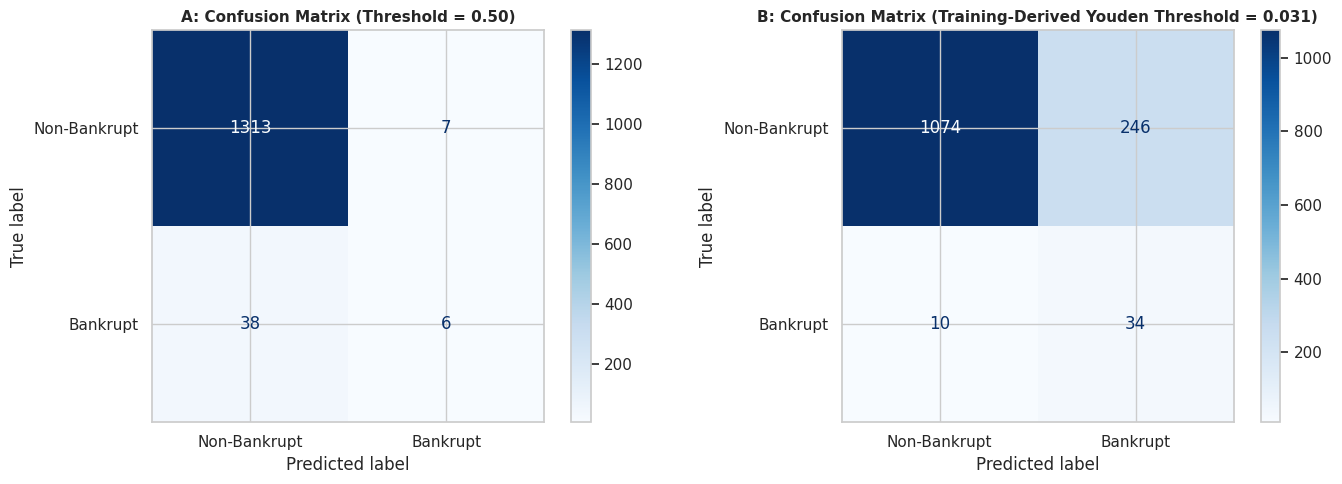


DECISION THRESHOLD COMPARISON (0.50 vs. OPTIMAL THRESHOLD)
                         Metric  Threshold 0.50  Optimal Threshold (Youden)
           Sensitivity (Recall)          0.1364                      0.7727
                    Specificity          0.9947                      0.8136
                Precision (PPV)          0.4615                      0.1214
NPV (Negative Predictive Value)          0.9719                      0.9908
                       F1-Score          0.2105                      0.2099


In [21]:
# 1. Standard Threshold (0.50) Evaluation
threshold_05 = 0.50
y_test_pred_05 = (pred_fe_probs >= threshold_05).astype(int)
cm_05 = confusion_matrix(y_test, y_test_pred_05)
tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()

sens_05 = recall_score(y_test, y_test_pred_05)
spec_05 = tn_05 / (tn_05 + fp_05)
prec_05 = precision_score(y_test, y_test_pred_05, zero_division=0)
npv_05 = tn_05 / (tn_05 + fn_05)
f1_05 = f1_score(y_test, y_test_pred_05, zero_division=0)

print("=" * 80)
print("CLASSIFICATION PERFORMANCE AT STANDARD THRESHOLD (0.50)")
print("=" * 80)
print(f"True Negatives (TN):  {tn_05:4d} | False Positives (FP): {fp_05:4d}")
print(f"False Negatives (FN): {fn_05:4d} | True Positives (TP):  {tp_05:4d}")
print(f"Sensitivity (Recall): {sens_05:.4f} | Specificity: {spec_05:.4f} | Precision: {prec_05:.4f} | NPV: {npv_05:.4f} | F1: {f1_05:.4f}")

# 2. Optimal Threshold Selection via Youden's J Statistic
# Threshold selected on training data only

# True labels of the cleaned training sample used to fit the GLMM
y_train_clean = train_glmm_df_clean['Bankrupt'].values

# Obtain predicted probabilities on the training sample
robjects.globalenv['train_data_threshold'] = pandas2ri.py2rpy(train_glmm_df_clean)

r_code_train_predict = """
pred_train_probs <- predict(
    glmm_model,
    newdata = train_data_threshold,
    type = "response",
    allow.new.levels = TRUE
)
pred_train_probs
"""

pred_train_probs = np.array(robjects.r(r_code_train_predict))

# Youden threshold selected only on training data
fpr_train, tpr_train, thresholds_train = roc_curve(
    y_train_clean,
    pred_train_probs
)

youden_idx = np.argmax(tpr_train - fpr_train)
optimal_threshold = thresholds_train[youden_idx]

print(f"Training-derived Youden threshold: {optimal_threshold:.4f}")


# Binary predictions using optimal threshold
y_pred_opt = (pred_fe_probs >= optimal_threshold).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

sens_opt = recall_score(y_test, y_pred_opt)
spec_opt = tn_opt / (tn_opt + fp_opt)
prec_opt = precision_score(y_test, y_pred_opt, zero_division=0)
npv_opt = tn_opt / (tn_opt + fn_opt)
f1_opt = f1_score(y_test, y_pred_opt, zero_division=0)

print("\n" + "=" * 80)
print(
    f"CLASSIFICATION PERFORMANCE AT TRAINING-DERIVED "
    f"YOUDEN THRESHOLD ({optimal_threshold:.4f})"
)
print("=" * 80)
print(f"True Negatives (TN):  {tn_opt:4d} | False Positives (FP): {fp_opt:4d}")
print(f"False Negatives (FN): {fn_opt:4d} | True Positives (TP):  {tp_opt:4d}")
print(f"Sensitivity (Recall): {sens_opt:.4f} | Specificity: {spec_opt:.4f} | Precision: {prec_opt:.4f} | NPV: {npv_opt:.4f} | F1: {f1_opt:.4f}")

print("\n=== CONFUSION MATRIX (Optimal Threshold) ===")
print(cm_opt)

print("\n=== CLASSIFICATION REPORT (Optimal Threshold) ===")
print(classification_report(y_test, y_pred_opt, target_names=['Sana (0)', 'Fallita (1)']))

# 3. Visual Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

disp_05 = ConfusionMatrixDisplay(confusion_matrix=cm_05, display_labels=['Non-Bankrupt', 'Bankrupt'])
disp_05.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('A: Confusion Matrix (Threshold = 0.50)', fontsize=11, fontweight='bold')

disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=['Non-Bankrupt', 'Bankrupt'])
disp_opt.plot(ax=ax2, cmap='Blues', values_format='d')
ax2.set_title(f"B: Confusion Matrix (Youden's J Threshold = {optimal_threshold:.3f})", fontsize=11, fontweight='bold')
ax2.set_title(f"B: Confusion Matrix " f"(Training-Derived Youden Threshold = {optimal_threshold:.3f})", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Comparison Table
threshold_comparison = pd.DataFrame({
    'Metric': ['Sensitivity (Recall)', 'Specificity', 'Precision (PPV)', 'NPV (Negative Predictive Value)', 'F1-Score'],
    'Threshold 0.50': [sens_05, spec_05, prec_05, npv_05, f1_05],
    'Optimal Threshold (Youden)': [sens_opt, spec_opt, prec_opt, npv_opt, f1_opt]
})

print("\n" + "=" * 80)
print("DECISION THRESHOLD COMPARISON (0.50 vs. OPTIMAL THRESHOLD)")
print("=" * 80)
print(threshold_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))